In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.8 MB/s eta 0:00:00


# 1. Import Library

In [2]:
import sys
import pandas as pd
import Bio
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import random

from tqdm.auto import tqdm 
from matplotlib.ticker import FuncFormatter
from sklearn.feature_extraction.text import CountVectorizer
from Bio import SeqIO
from IPython.display import display
from sklearn.model_selection import train_test_split
from itertools import cycle
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import ParameterGrid
pd.set_option('display.max_columns', None)

# 2. Import Data Fasta dan TSV

In [3]:
# 1. Mulai Timer
start_time = time.time()

# 2. Definisi Path File
fasta_file = "/kaggle/input/datasets/eliameylanis/dataset/0_dna-sequences-silva-v3-v4 (1).fasta"

# 3. Proses Loading FASTA (loop seperti kode asli kamu)
records = []
for i, record in enumerate(SeqIO.parse(fasta_file, "fasta")):
    records.append({
        "ID": record.id,
        "Deskripsi": record.description,
        "Sekuens": str(record.seq),
        "Panjang": len(record.seq)
    })

# 4. Buat DataFrame
datafasta = pd.DataFrame(records)

# 5. Laporan Output Linear
print(f"-> Total Baris  : {len(datafasta):,} sekuens")
print("-" * 60)

# 6. Preview Data (Agar Tampilan Rapi)
df_preview = datafasta.copy()

# Potong sekuens panjang
df_preview["Sekuens"] = df_preview["Sekuens"].apply(
    lambda s: f"{s[:6]}...{s[-6:]}"
)

print("\n[TOP 5 DATA AWAL (HEAD)]")
display(df_preview.head(5))

print("\n[BOTTOM 5 DATA AKHIR (TAIL)]")
display(df_preview.tail(5))

print("-" * 60)

# 7. Statistik Panjang Sekuens
stats_len = datafasta["Panjang"].describe()
print("STATISTIK PANJANG SEKUENS:")
print(f"-> Terpendek : {stats_len['min']:.0f} bp")
print(f"-> Terpanjang: {stats_len['max']:.0f} bp")
print(f"-> Rata-rata : {stats_len['mean']:.2f} bp")

# 8. Selesai
end_time = time.time()
print("="*60)
print(f"Waktu eksekusi total: {end_time - start_time:.2f} detik")
print("="*60)

-> Total Baris  : 398,508 sekuens
------------------------------------------------------------

[TOP 5 DATA AWAL (HEAD)]


,ID,Deskripsi,Sekuens,Panjang
0,CP013078.2406498.2408039,CP013078.2406498.2408039,TGGGGA...CAAACA,427
1,CP015924.1224168.1225721,CP015924.1224168.1225721,TGGGGA...CAAACA,427
2,CP003278.287486.289015,CP003278.287486.289015,TGGGGA...CAAACA,427
3,LS483321.16842.18378,LS483321.16842.18378,TAGGGA...CAAACA,427
4,CP012870.431955.433510,CP012870.431955.433510,TGGGGA...CAAACA,427



[BOTTOM 5 DATA AKHIR (TAIL)]


,ID,Deskripsi,Sekuens,Panjang
398503,X80629.1.1463,X80629.1.1463,TGGGGA...CGAACA,410
398504,X89947.1.1450,X89947.1.1450,TGGGGA...CGAACA,403
398505,ABCY02000001.445842.447355,ABCY02000001.445842.447355,CTAAGA...CAAACA,428
398506,Y10757.1.1502,Y10757.1.1502,TGGGGA...CAAACA,427
398507,Z76660.1.1493,Z76660.1.1493,TGGGGA...CAAACA,427


------------------------------------------------------------
STATISTIK PANJANG SEKUENS:
-> Terpendek : 51 bp
-> Terpanjang: 464 bp
-> Rata-rata : 416.31 bp
Waktu eksekusi total: 4.39 detik


In [4]:
# --- KONFIGURASI TAMPILAN PANDAS (PENTING) ---
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# 1. Mulai Timer
start_time = time.time()

tsv_file = "/kaggle/input/datasets/eliameylanis/dataset/0_taxonomy (1).tsv"

# 3. Load Data Taksonomi
datatax = pd.read_csv(tsv_file, sep="\t")

# 4. Rename Kolom (aman jika kolom tidak ada)
datatax.rename(columns={"Feature ID": "feature_id"}, inplace=True)

# 5. PREVIEW DATA MENTAH
print("-> Status Load    : Berhasil")
print(f"-> Total Baris    : {len(datatax):,} data")
print("-" * 60)

print("[TOP 5 DATA AWAL (RAW)]")
display(datatax.head(5))

print("\n[BOTTOM 5 DATA AKHIR (RAW)]")
display(datatax.tail(5))

print("-" * 60)

# 6. PROSES SPLIT & CLEANING
print("Sedang memproses pemecahan kolom 'Taxon'...")

# A. Hilangkan prefix taksonomi (d__, p__, c__, dst.)
datatax["Taxon_Clean"] = (
    datatax["Taxon"]
    .astype(str)
    .str.replace(r"[a-z]__", "", regex=True)
)

# B. Pecah berdasarkan delimiter '; '
df_split = datatax["Taxon_Clean"].str.split("; ", expand=True)

# C. Penamaan kolom level taksonomi
col_names = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
df_split.columns = col_names[:df_split.shape[1]]

# D. Gabungkan feature_id dengan hasil split
df_final_tax = pd.concat(
    [datatax[["feature_id"]], df_split],
    axis=1
)

# 7. PREVIEW DATA HASIL AKHIR
print(f"-> Status Proses  : Berhasil memecah menjadi {df_split.shape[1]} tingkatan taksonomi")
print("-" * 60)

print("[TOP 5 DATA HASIL]")
display(df_final_tax.head(5))

print("\n[BOTTOM 5 DATA HASIL]")
display(df_final_tax.tail(5))

print("-" * 60)

# 8. Selesai
end_time = time.time()
print("="*60)
print(f"Waktu eksekusi total: {end_time - start_time:.2f} detik")
print("="*60)

-> Status Load    : Berhasil
-> Total Baris    : 436,680 data
------------------------------------------------------------
[TOP 5 DATA AWAL (RAW)]


,feature_id,Taxon
0,CP013078.2406498.2408039,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Alcaligenaceae; g__Bordetella; s__Bordetella_pertussis
1,CP015924.1224168.1225721,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Enterobacterales; f__Enterobacteriaceae; g__Salmonella; s__Salmonella_enterica
2,CP003278.287486.289015,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Enterobacterales; f__Enterobacteriaceae; g__Salmonella; s__Salmonella_enterica
3,LS483321.16842.18378,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus; s__Streptococcus_pyogenes
4,CP012870.431955.433510,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Enterobacterales; f__Enterobacteriaceae; g__Escherichia-Shigella; s__Escherichia_coli



[BOTTOM 5 DATA AKHIR (RAW)]


,feature_id,Taxon
436675,X90756.1.1769,d__Eukaryota; p__Ascomycota; c__Saccharomycetes; o__Saccharomycetales; f__Saccharomycetaceae; g__Torulaspora; s__Torulaspora_microellipsoides
436676,X97777.1.1771,d__Eukaryota; p__Ascomycota; c__Saccharomycetes; o__Saccharomycetales; f__Saccharomycetaceae; g__Saccharomyces; s__Saccharomyces_bayanus
436677,ABCY02000001.445842.447355,d__Bacteria; p__Spirochaetota; c__Spirochaetia; o__Spirochaetales; f__Spirochaetaceae; g__Borreliella; s__Borreliella_valaisiana
436678,Y10757.1.1502,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Xanthomonadales; f__Xanthomonadaceae; g__Xanthomonas; s__Xanthomonas_arboricola
436679,Z76660.1.1493,d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Pseudomonadales; f__Pseudomonadaceae; g__Pseudomonas; s__Pseudomonas_coronafaciens


------------------------------------------------------------
Sedang memproses pemecahan kolom 'Taxon'...
-> Status Proses  : Berhasil memecah menjadi 7 tingkatan taksonomi
------------------------------------------------------------
[TOP 5 DATA HASIL]


,feature_id,Domain,Phylum,Class,Order,Family,Genus,Species
0,CP013078.2406498.2408039,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Alcaligenaceae,Bordetella,Bordetella_pertussis
1,CP015924.1224168.1225721,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
2,CP003278.287486.289015,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
3,LS483321.16842.18378,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,Streptococcus_pyogenes
4,CP012870.431955.433510,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia-Shigella,Escherichia_coli



[BOTTOM 5 DATA HASIL]


,feature_id,Domain,Phylum,Class,Order,Family,Genus,Species
436675,X90756.1.1769,Eukaryota,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Torulaspora,Torulaspora_microellipsoides
436676,X97777.1.1771,Eukaryota,Ascomycota,Saccharomycetes,Saccharomycetales,Saccharomycetaceae,Saccharomyces,Saccharomyces_bayanus
436677,ABCY02000001.445842.447355,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Spirochaetaceae,Borreliella,Borreliella_valaisiana
436678,Y10757.1.1502,Bacteria,Proteobacteria,Gammaproteobacteria,Xanthomonadales,Xanthomonadaceae,Xanthomonas,Xanthomonas_arboricola
436679,Z76660.1.1493,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas_coronafaciens


------------------------------------------------------------
Waktu eksekusi total: 5.42 detik


# 3. Merge Data (Menggabungkan Data)

In [5]:
# 1. Mulai Timer
start_time = time.time()

print("Sedang melakukan proses penggabungan data (Inner Join)...")

# 2. SAMAKAN NAMA KOLOM ID (WAJIB)
# FASTA: ID  -> feature_id
datafasta_merge = datafasta.rename(columns={"ID": "feature_id"})

# 3. Proses Merging (Inner Join)
df_merged = pd.merge(
    datafasta_merge,
    df_final_tax,
    on="feature_id",
    how="inner"
)

# 4. Laporan Statistik Merging
n_seq = len(datafasta)
n_tax = len(df_final_tax)
n_merged = len(df_merged)

print(f"-> Data Sekuens (FASTA)   : {n_seq:,} baris")
print(f"-> Data Taksonomi (TSV)   : {n_tax:,} baris")
print("-" * 40)
print(f"-> HASIL MERGE (MATCH)    : {n_merged:,} baris")
print(f"-> Data Hilang FASTA      : {n_seq - n_merged:,} baris (tanpa taksonomi)")

print("-" * 60)
print("PREVIEW DATASET TERINTEGRASI (SIAP ANALISIS):")

# 5. Preview Data
display(df_merged.head(5))
display(df_merged.tail(5))

# 6. Struktur Data Final
print("-" * 60)
print("STRUKTUR DATA FINAL:")
df_merged.info()

# 7. Simpan ke CSV
print("-" * 60)
output_filename = "datamerge.csv"
print(f"Sedang menyimpan hasil ke file '{output_filename}'...")

df_merged.to_csv(output_filename, index=False)

print("-> SUKSES! File berhasil disimpan.")

# 8. Selesai
end_time = time.time()
print("="*60)
print(f"Waktu eksekusi total: {end_time - start_time:.2f} detik")
print("="*60)

Sedang melakukan proses penggabungan data (Inner Join)...
-> Data Sekuens (FASTA)   : 398,508 baris
-> Data Taksonomi (TSV)   : 436,680 baris
----------------------------------------
-> HASIL MERGE (MATCH)    : 398,508 baris
-> Data Hilang FASTA      : 0 baris (tanpa taksonomi)
------------------------------------------------------------
PREVIEW DATASET TERINTEGRASI (SIAP ANALISIS):


,feature_id,Deskripsi,Sekuens,Panjang,Domain,Phylum,Class,Order,Family,Genus,Species
0,CP013078.2406498.2408039,CP013078.2406498.2408039,TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGCGTGTGCGATGAAGGCCTTCGGGTTGTAAAGCACTTTTGGCAGGAAAGAAACGGCACGGGCTAATATCCTGTGCAACTGACGGTACCTGCAGAATAAGCACCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGCAGGCGGTTCGGAAAGAAAGATGTGAAATCCCAGGGCTTAACCTTGGAACTGCATTTTTAACTACCGGGCTAGAGTGTGTCAGAGGGAGGTGGAATTCCGCGTGTAGCAGTGAAATGCGTAGATATGCGGAGGAACACCGATGGCGAAGGCAGCCTCCTGGGATAACACTGACGCTCATGCACGAAAGTGTGGGGAGCAAACA,427,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Alcaligenaceae,Bordetella,Bordetella_pertussis
1,CP015924.1224168.1225721,CP015924.1224168.1225721,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGTGTTGTGGTTAATAACCGCAGCAATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTCTGTCAAGTCGGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATTCGAAACTGGCAGGCTTGAGTCTTGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,427,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
2,CP003278.287486.289015,CP003278.287486.289015,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGTGTTGTGGTTAATAACCGCAGCAATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTCTGTCAAGTCGGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATTCGAAACTGGCAGGCTTGAGTCTTGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,427,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
3,LS483321.16842.18378,LS483321.16842.18378,TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGCGTGAGTGAAGAAGGTTTTCGGATCGTAAAGCTCTGTTGTTAGAGAAGAATGATGGTGGGAGTGGAAAATCCACCAAGTGACGGTAACTAACCAGAAAGGGACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTCCCGAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTTTTTAAGTCTGAAGTTAAAGGCATTGGCTCAACCAATGTACGCTTTGGAAACTGGAGAACTTGAGTGCAGAAGGGGAGAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGATATATGGAGGAACACCGGTGGCGAAAGCGGCTCTCTGGTCTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACA,427,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,Streptococcus_pyogenes
4,CP012870.431955.433510,CP012870.431955.433510,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGGAGTAAAGTTAATACCTTTGCTCATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGTCAGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCTGATACTGGCAAGCTTGAGTCTCGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACGAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,427,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia-Shigella,Escherichia_coli


,feature_id,Deskripsi,Sekuens,Panjang,Domain,Phylum,Class,Order,Family,Genus,Species
398503,X80629.1.1463,X80629.1.1463,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCGACCCCGCGTGGGGGATGAAGGCCTTCGGGTTGTAAACTCCTTTCGCTAGGGACGAAGCCTTATGGTGACGGTACCTGGAGAAGAAGCACCCGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGTGCGAGCGTTGTCCCGAATTACTGGGCGTAAAGAGCTCGTAGGTGGTTTGTCGCGTCGTCTTTGAAATCCCNGGGCTTAACTTCGGGCGTGCAGGCGATACGGGCATAACTTGAGTGCTGTAGGGGAGACTGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCAATGGCGAAGGCAGGTCTCTGGGCAGTAACTGACGCTGAGGAGCGAAAGCATGGGTAGCGAACA,410,Bacteria,Actinobacteriota,Actinobacteria,Corynebacteriales,Corynebacteriaceae,Corynebacterium,Corynebacterium_glutamicum
398504,X89947.1.1450,X89947.1.1450,TGGGGAATATTGCGCAATGGGCGAAAGCCTGACGCAGCGACGCCGCGTGGGGGATGACGGCCTTCGGGTTGTAAACCTCTTTCAGCAGGGACGAAGTTGACGTGTACCTGCAGAAGAAGCGCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGCGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGAGCTCGTAGGTGGCTTGTCACGTCGGGTGTGAAAGCTTGGGGCTTAACTCCAGGTCTGCATTCGATACGGGCTGGCTAGAGGTAGGTAGGGGAGAACGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCGGTGGCGAAGGCGGTTCTCTGGGCCTTACCTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACA,403,Bacteria,Actinobacteriota,Actinobacteria,Streptosporangiales,Streptosporangiaceae,Streptosporangium,Streptosporangium_roseum
398505,ABCY02000001.445842.447355,ABCY02000001.445842.447355,CTAAGAATCTTCCGCAATGGGCGAAAGCCTGACGGAGCGACACTGCGTGAATGAAGAAGGTCGAAAGATTGTAAAATTCTTTTATAAATGAGGAATAAGCTTTGTAGGAAATGACAAAGTGATGACGTTAATTTATGAATAAGCCCCGGCTAATTACGTGCCAGCAGCCGCGGTAATACGTAAGGGGCGAGCGTTGTTCGGGATTATTGGGCGTAAAGGGTGAGTAGGCGGACATATAAGTCTATGCATAAAATACCACAGCTCAACTGTGGAACTATGTTGGAAACTATATGCCTAGAGTCTGATAGAGGAAGTTAGAATTCCTGGTGTAAGGGTGGAATCTGTTGATATCAGGAAGAATACCGGAGGCGAAGGCGAACTTCTGGGTCAAGACTGACGCTGAGTCACGAAAGCGTAGGGAGCAAACA,428,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Spirochaetaceae,Borreliella,Borreliella_valaisiana
398506,Y10757.1.1502,Y10757.1.1502,TGGGGAATATTGGACAATGGGCGCAAGCCTGATCCAGCCATGCCGCGTGGGTGAAGAAGGCCTTCGGGTTGTAAAGCCCTTTTGTTGGGAAAGAAAAGCAGTCGGTTAATACCCGATTGTTCTGACGGTACCCAAAGAATAAGCACCGGCTAACTTCGTGCCAGCAGCCGCGGTAATACGAAGGGTGCAAGCGTTACTCGGAATTACTGGGCGTAAAGCGTGCGTAGGTGGTGGTTTAAGTCTGTTGTGAAAGCCCTGGGCTCAACCTGGGAATTGCAGTGGATACTGGGTCACTAGAGTGTGGTAGAGGGTAGCGGAATTCCCGGTGTAGCAGTGAAATGCGTAGAGATCGGGAGGAACATCCGTGGCGAAGGCGGCTACCTGGACCAACACTGACACTGAGGCACGAAAGCGTGGGGAGCAAACA,427,Bacteria,Proteobacteria,Gammaproteobacteria,Xanthomonadales,Xanthomonadaceae,Xanthomonas,Xanthomonas_arboricola
398507,Z76660.1.1493,Z76660.1.1493,TGGGGAATATTGGACAATGGGCGAAAGCCTGATCCAGCCATGCCGCGTGTGTGAAGAAGGTCTTCGGATTGTAAAGCACTTTAAGTTGGGAGGAAGGGCAGTTACCTAATACGTGATTGTTTTGACGTTACCGACAGAATAAGCACCGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGAGCGCGTAGGTGGTTTGTTAAGTTGGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCCAAAACTGGCAAGCTAGAGTATGGTAGAGGGTGGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGAACACCAGTGGCGAAGGCGACCACCTGGACTSATACTGACACTGAGGTGCGAAAGCGTGGGGASCAAACA,427,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas_coronafaciens


------------------------------------------------------------
STRUKTUR DATA FINAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398508 entries, 0 to 398507
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   feature_id  398508 non-null  object
 1   Deskripsi   398508 non-null  object
 2   Sekuens     398508 non-null  object
 3   Panjang     398508 non-null  int64 
 4   Domain      398508 non-null  object
 5   Phylum      398508 non-null  object
 6   Class       398508 non-null  object
 7   Order       398508 non-null  object
 8   Family      398508 non-null  object
 9   Genus       398508 non-null  object
 10  Species     398508 non-null  object
dtypes: int64(1), object(10)
memory usage: 33.4+ MB
------------------------------------------------------------
Sedang menyimpan hasil ke file 'datamerge.csv'...
-> SUKSES! File berhasil disimpan.
Waktu eksekusi total: 8.43 detik


# 4. Memilih Taksonomi Class dan Menggabungkan File Menjadi Format CSV

In [6]:
start_time = time.time()

merge_file = '/kaggle/working/datamerge.csv'


print(f"Sedang membaca file: {merge_file.split('/')[-1]}...")
df_all = pd.read_csv(merge_file)

print("-> Status Load : Berhasil")
print(f"-> Total data awal (semua domain) : {len(df_all):,}")
print("-" * 60)

# 3. FILTER DOMAIN = BACTERIA
df_bacteria = df_all[
    df_all['Domain'].astype(str).str.lower() == 'bacteria'
].copy()

print("FILTER DOMAIN: BACTERIA")
print(f"-> Total data Bacteria : {len(df_bacteria):,}")
print("-" * 60)

# 4. STATISTIK DATASET (LEVEL CLASS)
total_baris = len(df_bacteria)
dimensi = df_bacteria.shape
total_kelas = df_bacteria['Class'].nunique()

print(f"-> Dimensi Data           : {dimensi}")
print(f"-> TOTAL CLASS (BACTERIA) : {total_kelas} kelas")
print("-" * 60)

# 5. PREVIEW DATA
print("PREVIEW 5 DATA AWAL:")
df_head = df_bacteria[['Sekuens', 'Class']].head(5).copy()
df_head['Sekuens'] = df_head['Sekuens'].apply(
    lambda s: f"{str(s)[:3]}...{str(s)[-3:]}"
)
display(df_head)

print("\nPREVIEW 5 DATA AKHIR:")
df_tail = df_bacteria[['Sekuens', 'Class']].tail(5).copy()
df_tail['Sekuens'] = df_tail['Sekuens'].apply(
    lambda s: f"{str(s)[:3]}...{str(s)[-3:]}"
)
display(df_tail)
print("-" * 60)

# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

Sedang membaca file: datamerge.csv...
-> Status Load : Berhasil
-> Total data awal (semua domain) : 398,508
------------------------------------------------------------
FILTER DOMAIN: BACTERIA
-> Total data Bacteria : 368,859
------------------------------------------------------------
-> Dimensi Data           : (368859, 11)
-> TOTAL CLASS (BACTERIA) : 246 kelas
------------------------------------------------------------
PREVIEW 5 DATA AWAL:


,Sekuens,Class
0,TGG...ACA,Gammaproteobacteria
1,TGG...ACA,Gammaproteobacteria
2,TGG...ACA,Gammaproteobacteria
3,TAG...ACA,Bacilli
4,TGG...ACA,Gammaproteobacteria



PREVIEW 5 DATA AKHIR:


,Sekuens,Class
398503,TGG...ACA,Actinobacteria
398504,TGG...ACA,Actinobacteria
398505,CTA...ACA,Spirochaetia
398506,TGG...ACA,Gammaproteobacteria
398507,TGG...ACA,Gammaproteobacteria


------------------------------------------------------------
Waktu eksekusi: 4.28 detik


# 5. Visualisasi Distribusi Data

VISUALISASI BAB 3.1 – DOMAIN BACTERIA (TAKSONOMI CLASS)
-> Total data Bacteria : 368,859
-> Total Class         : 246
------------------------------------------------------------
[GRAFIK 1] Distribusi Class (10 Terbanyak & 10 Terdikit)


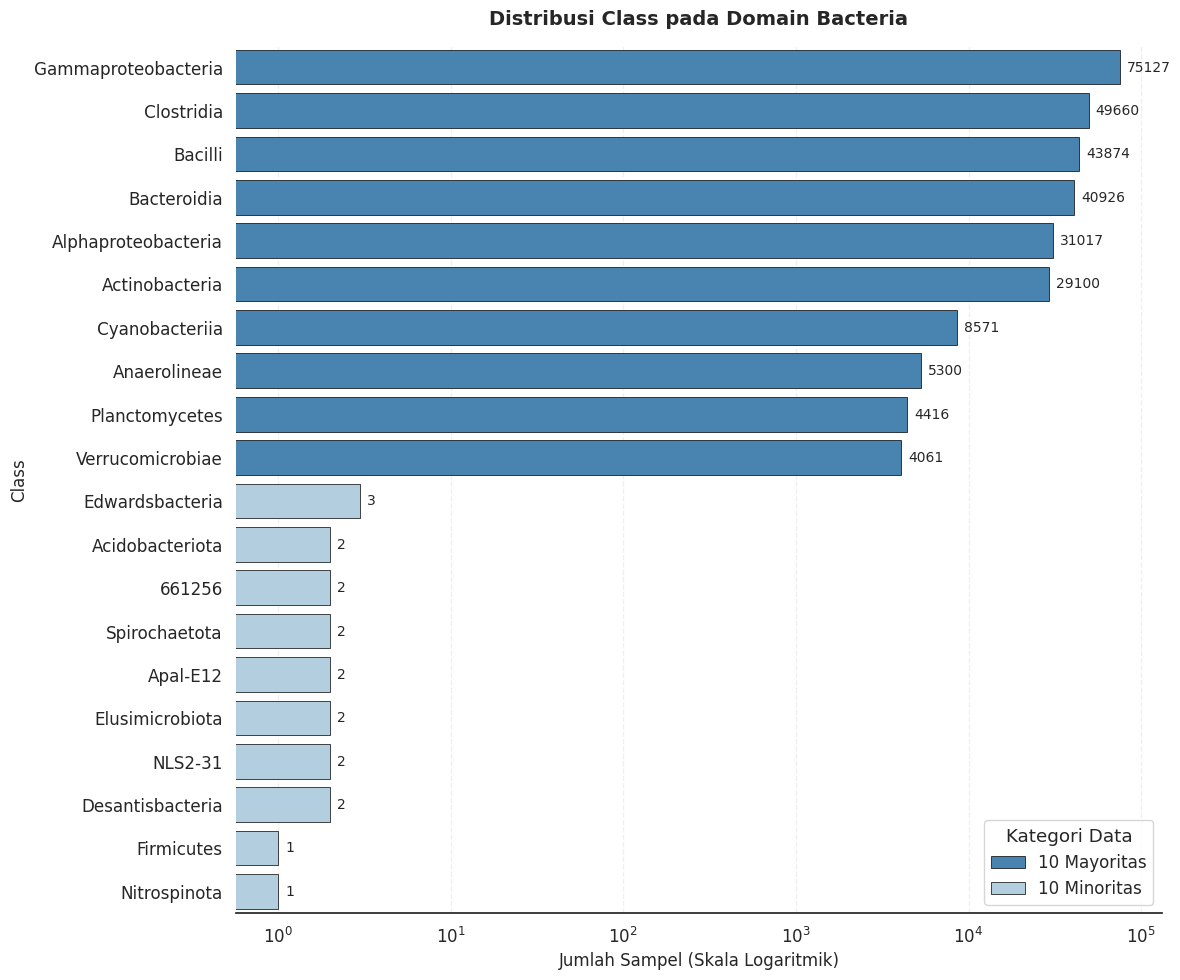


[GRAFIK 2] Distribusi Panjang Sekuens 16S rRNA


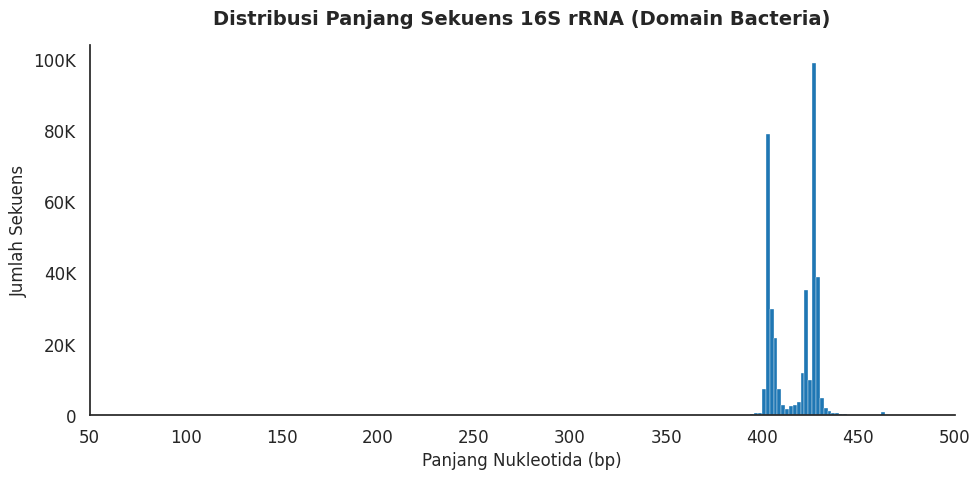


STATISTIK DESKRIPTIF BAB 3.1 (DOMAIN BACTERIA)
A. STATISTIK PANJANG SEKUENS
   -> Minimum : 51 bp
   -> Maksimum: 464 bp
   -> Rata-rata: 416.48 bp
   -> Modus    : 427 bp
------------------------------------------------------------
B. STATISTIK DISTRIBUSI CLASS
   -> Total Sampel   : 368,859
   -> Total Class    : 246
   -> Class Mayoritas: Gammaproteobacteria (75,127 sampel)
   -> Class Minoritas: Firmicutes (1 sampel)
   -> Rasio Max/Min  : 75127.00x (Imbalanced)
Waktu eksekusi: 3.84 detik


In [7]:
# 1. Mulai Timer
start_time = time.time()
from matplotlib.ticker import FuncFormatter

sns.set_style("white")
sns.set_context("notebook", font_scale=1.1)

print("="*60)
print("VISUALISASI BAB 3.1 – DOMAIN BACTERIA (TAKSONOMI CLASS)")
print("="*60)

# LOAD & FILTER DATA
df_bacteria = df_all[
    df_all['Domain'].astype(str).str.lower() == 'bacteria'
].copy()

print(f"-> Total data Bacteria : {len(df_bacteria):,}")
print(f"-> Total Class         : {df_bacteria['Class'].nunique()}")
print("-" * 60)

# BAGIAN 1: DISTRIBUSI CLASS (TOP 10 & BOTTOM 10)
print("[GRAFIK 1] Distribusi Class (10 Terbanyak & 10 Terdikit)")

# Hitung distribusi Class
raw_class_counts = df_bacteria['Class'].value_counts()

# Ambil 10 Terbanyak dan 10 Terdikit
top_10 = raw_class_counts.head(10).to_frame(name='Jumlah Sampel')
top_10['Kelompok'] = '10 Mayoritas'

bottom_10 = raw_class_counts.tail(10).to_frame(name='Jumlah Sampel')
bottom_10['Kelompok'] = '10 Minoritas'

# Gabungkan
df_viz_class = pd.concat([top_10, bottom_10])

# Plot
plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=df_viz_class,
    x='Jumlah Sampel',
    y=df_viz_class.index,
    hue='Kelompok',
    palette='Blues_r',
    dodge=False,
    edgecolor='black',
    linewidth=0.5
)

plt.xscale('log')

# Label angka
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontsize=10)

plt.title('Distribusi Class pada Domain Bacteria',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Sampel (Skala Logaritmik)', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.legend(title='Kategori Data')
sns.despine(left=True, bottom=False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("3_1_Distribusi_Class_TopBot10.png", dpi=300, bbox_inches='tight')
plt.show()

# BAGIAN 2: DISTRIBUSI PANJANG SEKUENS
print("\n[GRAFIK 2] Distribusi Panjang Sekuens 16S rRNA")

# Hitung panjang sekuens
seq_lengths = df_bacteria['Sekuens'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
ax = sns.histplot(
    seq_lengths,
    binwidth=2,
    edgecolor=None,
    alpha=1.0
)

plt.xlim(50, 500)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}')
)

plt.title('Distribusi Panjang Sekuens 16S rRNA (Domain Bacteria)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Panjang Nukleotida (bp)', fontsize=12)
plt.ylabel('Jumlah Sekuens', fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig("3_1_Panjang_Sekuens_Bacteria.png", dpi=300, bbox_inches='tight')
plt.show()

# BAGIAN 3: STATISTIK DESKRIPTIF (UNTUK NARASI SKRIPSI)
print("\n" + "="*60)
print("STATISTIK DESKRIPTIF BAB 3.1 (DOMAIN BACTERIA)")
print("="*60)

# --- A. STATISTIK PANJANG SEKUENS ---
print("A. STATISTIK PANJANG SEKUENS")
print(f"   -> Minimum : {seq_lengths.min()} bp")
print(f"   -> Maksimum: {seq_lengths.max()} bp")
print(f"   -> Rata-rata: {seq_lengths.mean():.2f} bp")
print(f"   -> Modus    : {seq_lengths.mode()[0]} bp")
print("-" * 60)

# --- B. STATISTIK DISTRIBUSI CLASS ---
class_counts = df_bacteria['Class'].value_counts()

print("B. STATISTIK DISTRIBUSI CLASS")
print(f"   -> Total Sampel   : {len(df_bacteria):,}")
print(f"   -> Total Class    : {df_bacteria['Class'].nunique()}")
print(f"   -> Class Mayoritas: {class_counts.idxmax()} ({class_counts.max():,} sampel)")
print(f"   -> Class Minoritas: {class_counts.idxmin()} ({class_counts.min()} sampel)")
print(f"   -> Rasio Max/Min  : {class_counts.max()/class_counts.min():.2f}x (Imbalanced)")
print("="*60)

# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

# 6. Distribusi Panjang Sekuens

In [8]:
# 1. Mulai Timer
start_time = time.time()
# CEK SEBARAN PANJANG SEKUENS (DOMAIN BACTERIA)

print("Statistik Panjang Sekuens (bp):")

# Hitung panjang sekuens dari kolom 'Sekuens'
df_bacteria['panjang_sekuens'] = df_bacteria['Sekuens'].astype(str).apply(len)

# Statistik deskriptif
print(df_bacteria['panjang_sekuens'].describe())

# SIMULASI FILTER PANJANG SEKUENS
cutoff_400 = df_bacteria[df_bacteria['panjang_sekuens'] < 400].shape[0]
cutoff_300 = df_bacteria[df_bacteria['panjang_sekuens'] < 300].shape[0]

print(f"\nJumlah data di bawah 400 bp : {cutoff_400:,} baris")
print(f"Jumlah data di bawah 300 bp : {cutoff_300:,} baris")
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

Statistik Panjang Sekuens (bp):
count    368859.000000
mean        416.479216
std          13.280993
min          51.000000
25%         404.000000
50%         422.000000
75%         427.000000
max         464.000000
Name: panjang_sekuens, dtype: float64

Jumlah data di bawah 400 bp : 3,246 baris
Jumlah data di bawah 300 bp : 353 baris
Waktu eksekusi: 0.20 detik


# 7. Pembersihan Data

✓ Setelah drop NA: 368,859 baris
✓ Baris dihapus karena Class 'uncultured': 553
  - Sisa data: 368,306

[2/7] Standardisasi Sekuens...
✓ Sekuens diubah ke uppercase dan di-trim

[3/7] Filter Panjang Sekuens...
✓ Filter panjang sekuens (400-550 bp)
  - Awal  : 368,306
  - Lolos : 365,065
  - Dibuang: 3,241

[4/7] Deduplikasi Sekuens...
✓ Deduplikasi selesai: 278,169 baris
  - Duplikat dihapus: 86,896

[6/7] Filter Class dengan Minimal Sampel...
✓ Filter Class (n ≥ 25)
  - Data sebelum filter: 278,169
  - Data final: 277,586
  - Total Class akhir: 178

[7/7] Membuat Analisis Perbandingan...

ANALISIS PERBANDINGAN CLASS

[TOP 10 CLASS TERBANYAK]


,1. Raw (Sebelum Dedup),2. Unik (Sesudah Dedup),3. Final,Duplikat Dibuang,% Redundansi,Status
Class,,,,,,
Gammaproteobacteria,75127,52732,52732,22395,29.81,Lolos
Clostridia,49660,36681,36681,12979,26.14,Lolos
Bacilli,43874,26626,26626,17248,39.31,Lolos
Bacteroidia,40926,34529,34529,6397,15.63,Lolos
Alphaproteobacteria,31017,22600,22600,8417,27.14,Lolos
Actinobacteria,29100,18000,18000,11100,38.14,Lolos
Cyanobacteriia,8571,7082,7082,1489,17.37,Lolos
Anaerolineae,5300,4600,4600,700,13.21,Lolos
Planctomycetes,4416,4268,4268,148,3.35,Lolos



[CLASS YANG DIBUANG (n < 25)]
Total: 67 kelas


,1. Raw (Sebelum Dedup),2. Unik (Sesudah Dedup),3. Final,Duplikat Dibuang,% Redundansi,Status
Class,,,,,,
WWE3,84,15,0,69,82.14,Dibuang
Natranaerobiia,27,24,0,3,11.11,Dibuang
Desulfarculia,27,23,0,4,14.81,Dibuang
4-29,23,23,0,0,0.00,Dibuang
BMS9AB35,22,22,0,0,0.00,Dibuang
AncK6,22,21,0,1,4.55,Dibuang
CK-2C2-2,21,21,0,0,0.00,Dibuang
Lineage_IIc,21,21,0,0,0.00,Dibuang
ODP123,20,20,0,0,0.00,Dibuang



VISUALISASI DAMPAK DEDUPLIKASI


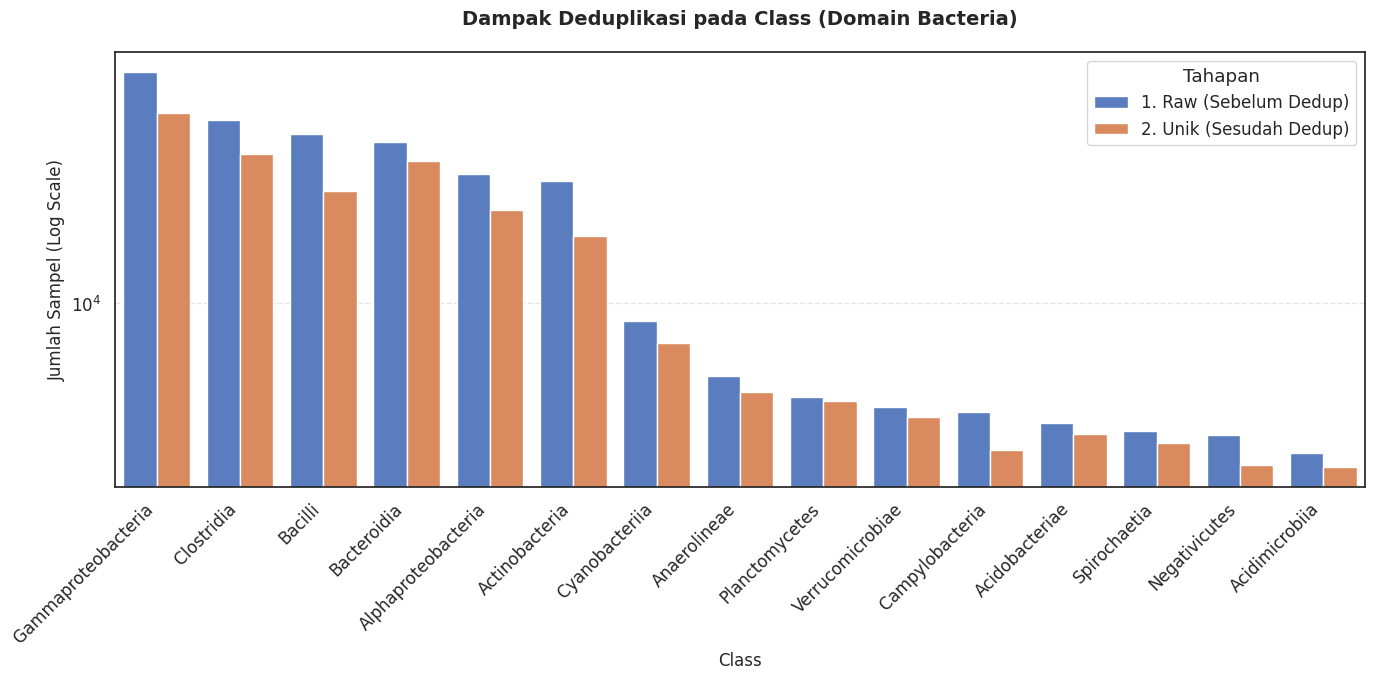

✓ Grafik tersimpan: visualisasi_deduplikasi.png

PREVIEW DATA FINAL

5 Data Pertama:


,Sekuens,Class
0,TGGGGAATTTTGGACAATGGGGGCAACCCT...GCTCATGCACGAAAGTGTGGGGAGCAAACA,Gammaproteobacteria
1,TGGGGAATATTGCACAATGGGCGCAAGCCT...GCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
3,TAGGGAATCTTCGGCAATGGGGGCAACCCT...GCTGAGGCTCGAAAGCGTGGGGAGCAAACA,Bacilli
4,TGGGGAATATTGCACAATGGGCGCAAGCCT...GCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
5,TGGGGAATATTGGACAATGGGGGGAACCCT...GCTGAGGTACGAAAGCATGGGGAGCAAACA,Gammaproteobacteria



5 Data Terakhir:


,Sekuens,Class
397637,TGGGGAATATTGCACAATGGGCGCAAGCCT...GCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
397639,TGGGGAATATTGCACAATGGGGGAAACCCT...GCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
397640,TGGGGAATATTGCACAATGGGGGAAACCCT...GCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
397642,TGGGGAATATTGCACAATGGGCGCAAGCCT...GCTGAGGAGCGAAAGCATGGGGAGCGAACA,Actinobacteria
397643,TTAAGAATCTTGCTCAATGGGCGAAAGCCT...GCTGAAACACGAAAGCGTGGGTAGTGAACG,Leptospirae



RINGKASAN PREPROCESSING
Data awal (Bacteria)        : 368,859
Setelah drop NA             : 278,169
Setelah filter panjang      : 368,306
Setelah deduplikasi         : 365,065
Setelah filter min samples  : 277,586

Total Class akhir           : 178
Waktu eksekusi              : 3.44 detik
Data sebelum hapus 'uncultured' : 368,859
Data sesudah hapus 'uncultured' : 368,306
Total baris terhapus           : 553


In [9]:
start_time = time.time()

# =============================================================================
# 1. DROP MISSING VALUES (CLASS & SEKUENS)
# =============================================================================
df_processed = df_bacteria.dropna(subset=['Class', 'Sekuens']).copy()
print(f"✓ Setelah drop NA: {len(df_processed):,} baris")

# =============================================================================
# 1b. HAPUS CLASS UNCULTURED
# =============================================================================
n_before_uncultured = len(df_processed)
df_processed = df_processed[~df_processed['Class'].str.contains('uncultured', case=False)].copy()
n_after_uncultured = len(df_processed)

print(f"✓ Baris dihapus karena Class 'uncultured': {n_before_uncultured - n_after_uncultured:,}")
print(f"  - Sisa data: {n_after_uncultured:,}")

# 2. STANDARDISASI SEKUENS
# =============================================================================
print("\n[2/7] Standardisasi Sekuens...")
df_processed['Sekuens'] = (
    df_processed['Sekuens']
    .astype(str)
    .str.upper()
    .str.strip()
)
print(f"✓ Sekuens diubah ke uppercase dan di-trim")

# Snapshot awal
count_raw = df_processed['Class'].value_counts().rename('1. Raw (Sebelum Dedup)')

# =============================================================================
# 3. FILTER PANJANG SEKUENS (400–550 bp)
# =============================================================================
print("\n[3/7] Filter Panjang Sekuens...")
MIN_LEN = 400
MAX_LEN = 550

df_processed['seq_length'] = df_processed['Sekuens'].str.len()
n_before = len(df_processed)

df_processed = df_processed[
    (df_processed['seq_length'] >= MIN_LEN) &
    (df_processed['seq_length'] <= MAX_LEN)
].copy()

print(f"✓ Filter panjang sekuens ({MIN_LEN}-{MAX_LEN} bp)")
print(f"  - Awal  : {n_before:,}")
print(f"  - Lolos : {len(df_processed):,}")
print(f"  - Dibuang: {n_before - len(df_processed):,}")

# =============================================================================
# 4. DEDUPLIKASI SEKUENS
# =============================================================================
print("\n[4/7] Deduplikasi Sekuens...")
n_before_dedup = len(df_processed)
df_processed = df_processed.drop_duplicates(subset=['Sekuens'], keep='first')

print(f"✓ Deduplikasi selesai: {len(df_processed):,} baris")
print(f"  - Duplikat dihapus: {n_before_dedup - len(df_processed):,}")

count_dedup = df_processed['Class'].value_counts().rename('2. Unik (Sesudah Dedup)')

# =============================================================================
# 6. FILTER CLASS (HANYA CLASS DENGAN n ≥ MIN_SAMPLES)
# =============================================================================
print("\n[6/7] Filter Class dengan Minimal Sampel...")
MIN_SAMPLES = 25

class_counts = df_processed['Class'].value_counts()
class_to_keep = class_counts[class_counts >= MIN_SAMPLES].index
n_before_filter = len(df_processed)
df_final = df_processed[df_processed['Class'].isin(class_to_keep)].copy()

print(f"✓ Filter Class (n ≥ {MIN_SAMPLES})")
print(f"  - Data sebelum filter: {n_before_filter:,}")
print(f"  - Data final: {len(df_final):,}")
print(f"  - Total Class akhir: {df_final['Class'].nunique()}")

count_final = df_final['Class'].value_counts().rename('3. Final')

# =============================================================================
# 7. ANALISIS PERBANDINGAN
# =============================================================================
print("\n[7/7] Membuat Analisis Perbandingan...")

comparison_df = pd.concat(
    [count_raw, count_dedup, count_final],
    axis=1
).fillna(0).astype(int)

comparison_df['Duplikat Dibuang'] = (
    comparison_df['1. Raw (Sebelum Dedup)'] -
    comparison_df['2. Unik (Sesudah Dedup)']
)

comparison_df['% Redundansi'] = (
    comparison_df['Duplikat Dibuang'] /
    comparison_df['1. Raw (Sebelum Dedup)'] * 100
).round(2)

comparison_df['Status'] = comparison_df['3. Final'].apply(
    lambda x: 'Lolos' if x > 0 else 'Dibuang'
)

comparison_df = comparison_df.sort_values(
    by='1. Raw (Sebelum Dedup)', ascending=False
)

# =============================================================================
# 8. TAMPILKAN HASIL ANALISIS
# =============================================================================
print("\n" + "=" * 70)
print("ANALISIS PERBANDINGAN CLASS")
print("=" * 70)

print("\n[TOP 10 CLASS TERBANYAK]")
try:
    display(comparison_df.head(10))
except:
    print(comparison_df.head(10).to_string())

classes_dibuang = comparison_df[comparison_df['Status'] == 'Dibuang']
if len(classes_dibuang) > 0:
    print(f"\n[CLASS YANG DIBUANG (n < {MIN_SAMPLES})]")
    print(f"Total: {len(classes_dibuang)} kelas")
    try:
        display(classes_dibuang.head(20))
    except:
        print(classes_dibuang.head(20).to_string())
else:
    print(f"\n✓ Tidak ada class yang dibuang")

# =============================================================================
# 9. VISUALISASI DAMPAK DEDUPLIKASI
# =============================================================================
print("\n" + "=" * 70)
print("VISUALISASI DAMPAK DEDUPLIKASI")
print("=" * 70)

sns.set_style("white")
plt.figure(figsize=(14, 7))

top_15 = comparison_df.head(15).reset_index()
top_15 = top_15.rename(columns={'index': 'Class'})

melted_plot = top_15.melt(
    id_vars='Class',
    value_vars=['1. Raw (Sebelum Dedup)', '2. Unik (Sesudah Dedup)'],
    var_name='Tahapan',
    value_name='Jumlah Sampel'
)

sns.barplot(
    data=melted_plot,
    x='Class',
    y='Jumlah Sampel',
    hue='Tahapan',
    palette='muted'
)

plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Dampak Deduplikasi pada Class (Domain Bacteria)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Jumlah Sampel (Log Scale)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

filename = 'visualisasi_deduplikasi.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Grafik tersimpan: {filename}")

# =============================================================================
# 10. PREVIEW DATA FINAL
# =============================================================================
print("\n" + "=" * 70)
print("PREVIEW DATA FINAL")
print("=" * 70)

print("\n5 Data Pertama:")
df_preview_head = df_final[['Sekuens', 'Class']].head(5).copy()
df_preview_head['Sekuens'] = df_preview_head['Sekuens'].apply(
    lambda s: f"{s[:30]}...{s[-30:]}"
)
try:
    display(df_preview_head)
except:
    print(df_preview_head.to_string(index=False))

print("\n5 Data Terakhir:")
df_preview_tail = df_final[['Sekuens', 'Class']].tail(5).copy()
df_preview_tail['Sekuens'] = df_preview_tail['Sekuens'].apply(
    lambda s: f"{s[:30]}...{s[-30:]}"
)
try:
    display(df_preview_tail)
except:
    print(df_preview_tail.to_string(index=False))

# =============================================================================
# 11. RINGKASAN
# =============================================================================
end_time = time.time()
execution_time = end_time - start_time

print("\n" + "=" * 70)
print("RINGKASAN PREPROCESSING")
print("=" * 70)
print(f"Data awal (Bacteria)        : {len(df_bacteria):,}")
print(f"Setelah drop NA             : {len(df_processed):,}")
print(f"Setelah filter panjang      : {n_before:,}")
print(f"Setelah deduplikasi         : {n_before_dedup:,}")
print(f"Setelah filter min samples  : {len(df_final):,}")
print(f"\nTotal Class akhir           : {df_final['Class'].nunique()}")
print(f"Waktu eksekusi              : {execution_time:.2f} detik")
print(f"Data sebelum hapus 'uncultured' : {n_before_uncultured:,}")
print(f"Data sesudah hapus 'uncultured' : {n_after_uncultured:,}")
print(f"Total baris terhapus           : {n_before_uncultured - n_after_uncultured:,}")
print("=" * 70)

In [10]:
print("\n" + "=" * 70)
print("DATA SETELAH PEMBERSIHAN (FINAL DATASET)")
print("=" * 70)

print(f"\nTotal sampel akhir: {len(df_final):,}")

print("\n5 Data Pertama:")
df_first5 = df_final[['Sekuens', 'Class']].head(5)
display(df_first5)

print("\n5 Data Terakhir:")
df_last5 = df_final[['Sekuens', 'Class']].tail(5)
display(df_last5)


DATA SETELAH PEMBERSIHAN (FINAL DATASET)

Total sampel akhir: 277,586

5 Data Pertama:


,Sekuens,Class
0,TGGGGAATTTTGGACAATGGGGGCAACCCTGATCCAGCCATCCCGCGTGTGCGATGAAGGCCTTCGGGTTGTAAAGCACTTTTGGCAGGAAAGAAACGGCACGGGCTAATATCCTGTGCAACTGACGGTACCTGCAGAATAAGCACCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGCAGGCGGTTCGGAAAGAAAGATGTGAAATCCCAGGGCTTAACCTTGGAACTGCATTTTTAACTACCGGGCTAGAGTGTGTCAGAGGGAGGTGGAATTCCGCGTGTAGCAGTGAAATGCGTAGATATGCGGAGGAACACCGATGGCGAAGGCAGCCTCCTGGGATAACACTGACGCTCATGCACGAAAGTGTGGGGAGCAAACA,Gammaproteobacteria
1,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGTGTTGTGGTTAATAACCGCAGCAATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTCTGTCAAGTCGGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATTCGAAACTGGCAGGCTTGAGTCTTGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
3,TAGGGAATCTTCGGCAATGGGGGCAACCCTGACCGAGCAACGCCGCGTGAGTGAAGAAGGTTTTCGGATCGTAAAGCTCTGTTGTTAGAGAAGAATGATGGTGGGAGTGGAAAATCCACCAAGTGACGGTAACTAACCAGAAAGGGACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTCCCGAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTTTTTAAGTCTGAAGTTAAAGGCATTGGCTCAACCAATGTACGCTTTGGAAACTGGAGAACTTGAGTGCAGAAGGGGAGAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGATATATGGAGGAACACCGGTGGCGAAAGCGGCTCTCTGGTCTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACA,Bacilli
4,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTATGAAGAAGGCCTTCGGGTTGTAAAGTACTTTCAGCGGGGAGGAAGGGAGTAAAGTTAATACCTTTGCTCATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGTCAGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCTGATACTGGCAAGCTTGAGTCTCGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACGAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
5,TGGGGAATATTGGACAATGGGGGGAACCCTGATCCAGCCATGCCGCGTGTGTGAAGAAGGCCTTATGGTTGTAAAGCACTTTAAGCGAGGAGGAGGCTACTTTAGTTAATACCTAGAGATAGTGGACGTTACTCGCAGAATAAGCACCGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGGTGCGAGCGTTAATCGGATTTACTGGGCGTAAAGCGTGCGTAGGCGGCTTATTAAGTCGGATGTGAAATCCCCGAGCTTAACTTGGGAATTGCATTCGATACTGGTGAGCTAGAGTATGGGAGAGGATGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGATGGCGAAGGCAGCCATCTGGCCTAATACTGACGCTGAGGTACGAAAGCATGGGGAGCAAACA,Gammaproteobacteria



5 Data Terakhir:


,Sekuens,Class
397637,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCCATGCCGCGTGTGTGAAGAAGGCCTTCGGGTTGTAAAGCRCTTTCNGCGGGGAGGAAGGCAGTAAGGTTAATAACCTTGCTGATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATGACTGGGCGTAAAGCGCACGCAGGCGGTCTGTTAAGTTGGATGTGAAATCCCCGGGCTTAACCTGGGAACTGCATTCAAAACTGACAGGCTAGAGTCTTGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
397639,TGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCCATGCCGCGTGTGTGAAGAAGGCCTTCGGGTTGTAAAGCACTTTCAGCGGGGAGGAAGGGGACAGGCTTAATACGTCTGTTCATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATGACTGGGCGTAAAGCGCACGCAGGCGGTCTGTTAAGTTGGATGTGAAATCCCCGGGCTTAACCTGGGAACTGCATTCAAAACTGACAGGCTAGAGTCTCGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACGAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
397640,TGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCCATGCCGCGTGTGTGAAGAAGGCCTTCGGGTTGTAAAGCACTTTCAGCGGGGAGGAAGGCGATAAACTTAATAAGTTTGTTGATTGACGTTACCCGCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATGACTGGGCGTAAAGCGCACGCAGGCGGTGTGTTAAGTTGGATGTGAAATCCCCGGGCTCAACCCGGGAACAGCATTCAAAACTGACAGGCTAGAGTCTCGTAGAGGGGGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACGAAGACTGACGCTCAGGTGCGAAAGCGTGGGGAGCAAACA,Gammaproteobacteria
397642,TGGGGAATATTGCACAATGGGCGCAAGCCTGATGCAGCGACGCCGCGTGGGGGATKGAAGGCTTCGGGTTGTAAACTCCTTTCGCCCGGGACGAAGCCCACCTGGTGGGTGACGGTACCGTGGAGAAGAAGCACCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTGTCCGGATTTACTGGGCGTAAAGAGCTCGTAGGTGGTGTGTCGCGTCGTCTGTGAAATTCCGGGGCTTAACTCCGGGCGTGCAGGCGATACGGGCACGACTAGAGTGCTGTAGGGGTAACTGGAATTCCTGGTGTAGCGGTGAAATGCGCAGATATCAGGAGGAACACCGATGGCGAAGGCAGGTTACTGGGCAGTTACTGACGCTGAGGAGCGAAAGCATGGGGAGCGAACA,Actinobacteria
397643,TTAAGAATCTTGCTCAATGGGCGAAAGCCTGAAGCAGCGACGCCGCGTGAACGATGAAGGTCTTCGGATTGTAAAGTTCAGTAAGTAGGGACGAAAAAAATGACGGTACCTACCTAAAGCACCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTACTGGTGCAAGCGTTGTTCGGAATCATTGGGCGTAAAGGGTGTGTAGGCGGACTAACAAGTCAGGTGTGAAATCTTCGGGCTCAACTCGAAACCTGCATTTGAAACTGTTAGTCTGGAATCTGGGAGAGGCAAGTGGAATTTCTGGTGTAGCGGTGAAATGCGTAGATATCAGAAGGAACACCGATGGCGAAGGCAACTTGCTGGCCTAAGATTGACGCTGAAACACGAAAGCGTGGGTAGTGAACG,Leptospirae


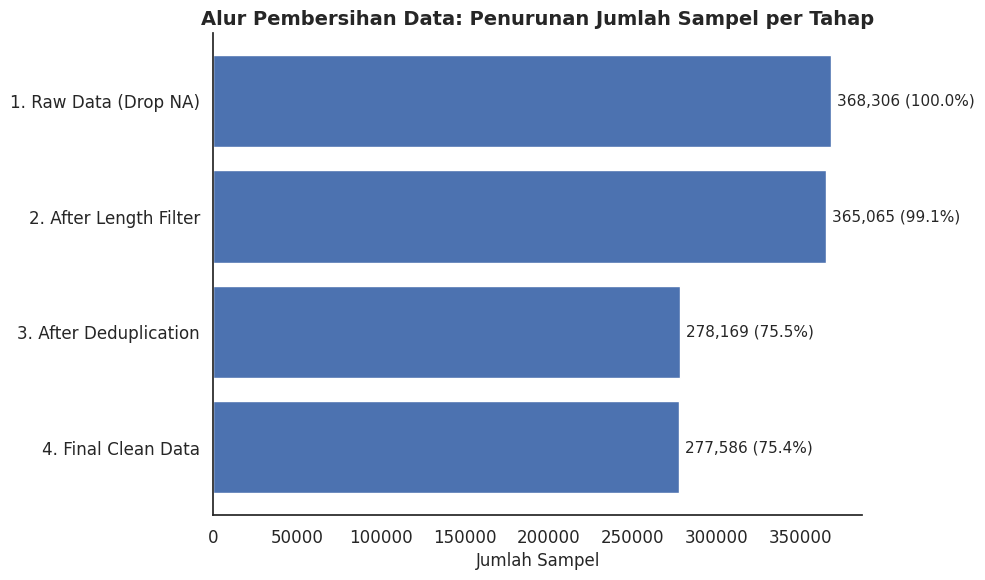

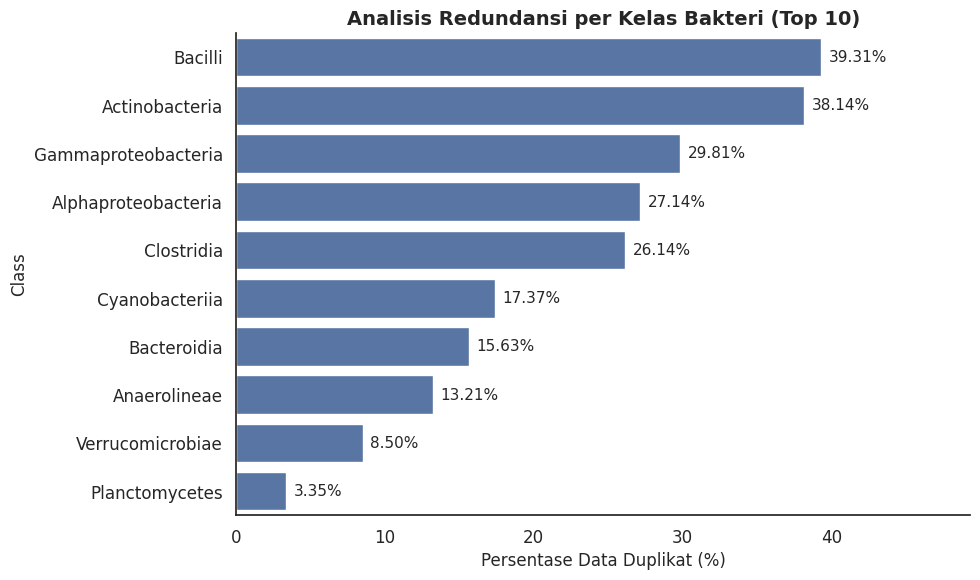

Waktu eksekusi: 1.18 detik
Visualisasi selesai: Times New Roman, teks normal, akademis.


In [11]:
# 1. Mulai Timer
start_time = time.time()
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_style("white")

academic_blue = '#4C72B0'

counts = [count_raw.sum(), n_before_dedup, len(df_processed), len(df_final)]
labels = [
    '1. Raw Data (Drop NA)', 
    '2. After Length Filter', 
    '3. After Deduplication', 
    '4. Final Clean Data'
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    labels[::-1],
    counts[::-1],
    color=academic_blue
)

total_initial = counts[0]

for bar in bars[::-1]:
    width = bar.get_width()
    percentage = (width / total_initial) * 100
    plt.text(
        width + (total_initial * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,} ({percentage:.1f}%)',
        va='center',
        fontsize=11
    )

plt.title(
    'Alur Pembersihan Data: Penurunan Jumlah Sampel per Tahap',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Jumlah Sampel', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('funnel_tnr.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))

top_redundancy = comparison_df.head(10).sort_values('% Redundansi', ascending=False)

ax = sns.barplot(
    data=top_redundancy,
    x='% Redundansi',
    y=top_redundancy.index,
    color=academic_blue
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.5,
        p.get_y() + p.get_height() / 2,
        f'{width:.2f}%',
        va='center',
        fontsize=11
    )

plt.title(
    'Analisis Redundansi per Kelas Bakteri (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Persentase Data Duplikat (%)', fontsize=12)
plt.ylabel('Class', fontsize=12)

plt.xlim(0, max(top_redundancy['% Redundansi']) + 10)

sns.despine()
plt.tight_layout()
plt.savefig('redundancy_tnr.png', dpi=300)
plt.show()
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

print("Visualisasi selesai: Times New Roman, teks normal, akademis.")

# 8. Penanganan Basa Ambigu

In [12]:
import random
import pandas as pd
from IPython.display import display

# 1. Mulai Timer
start_time = time.time()
# 1. Setup Konfigurasi
random.seed(42)
iupac_map = {
    'N': ['A', 'C', 'G', 'T'], 'R': ['A', 'G'], 'Y': ['C', 'T'],
    'S': ['G', 'C'], 'W': ['A', 'T'], 'K': ['G', 'T'], 'M': ['A', 'C'],
    'B': ['C', 'G', 'T'], 'D': ['A', 'G', 'T'], 'H': ['A', 'C', 'T'],
    'V': ['A', 'C', 'G']
}
standard_bases = {'A', 'C', 'G', 'T'}

# 2. Fungsi Pembersihan yang Lebih Informatif
def clean_and_log(seq):
    if not isinstance(seq, str): return "", 0, []
    seq = seq.upper()
    cleaned = []
    changes_count = 0
    changed_chars = []
    
    for base in seq:
        if base in standard_bases:
            cleaned.append(base)
        else:
            replacement = random.choice(iupac_map.get(base, [base]))
            cleaned.append(replacement)
            changes_count += 1
            changed_chars.append(base)
            
    return "".join(cleaned), changes_count, list(set(changed_chars))

# 3. Eksekusi Proses
print("="*60)
print("PROSES PEMBERSIHAN KARAKTER AMBIGU (IUPAC RESOLUTION)")
print("="*60)

# Simpan hasil ke kolom sementara agar lebih terstruktur
results = df_final['Sekuens'].apply(clean_and_log)
df_final['Sekuens_cleaned'] = results.apply(lambda x: x[0])
df_final['Jml_Perubahan'] = results.apply(lambda x: x[1])
df_final['Karakter_Ditemukan'] = results.apply(lambda x: x[2])

# 4. Tampilkan Perbandingan yang Informatif
df_changed = df_final[df_final['Jml_Perubahan'] > 0].copy()

if not df_changed.empty:
    print(f"Deteksi: Ditemukan {len(df_changed):,} sekuens dengan karakter non-standar.")
    print(f"Total karakter yang disubstitusi: {df_changed['Jml_Perubahan'].sum():,} karakter.")
    
    # Menampilkan contoh perubahan dengan kolom yang rapi
    example_display = df_changed[['Class', 'Sekuens', 'Sekuens_cleaned', 'Jml_Perubahan', 'Karakter_Ditemukan']].head(10)
    
    # Percantik tampilan sekuens agar tidak terlalu panjang di tabel
    example_display['Sekuens'] = example_display['Sekuens'].apply(lambda x: f"{x[:20]}...{x[-10:]}")
    example_display['Sekuens_cleaned'] = example_display['Sekuens_cleaned'].apply(lambda x: f"{x[:20]}...{x[-10:]}")
    
    display(example_display)
else:
    print("Semua data sudah bersih. Tidak ditemukan kode IUPAC.")

# 5. Verifikasi Akhir
all_chars = set("".join(df_final['Sekuens_cleaned'].astype(str)))
print("-" * 60)
print(f"VERIFIKASI KARAKTER FINAL: {all_chars}")
if all_chars.issubset(standard_bases):
    print("STATUS: AMAN (Hanya mengandung A, C, G, T)")
else:
    print("STATUS: PERINGATAN (Masih ditemukan karakter non-standar!)")
print("-" * 60)
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

PROSES PEMBERSIHAN KARAKTER AMBIGU (IUPAC RESOLUTION)
Deteksi: Ditemukan 11,184 sekuens dengan karakter non-standar.
Total karakter yang disubstitusi: 16,083 karakter.


,Class,Sekuens,Sekuens_cleaned,Jml_Perubahan,Karakter_Ditemukan
3289,Campylobacteria,TAGGGAATATTGCTCAATGG...GGAGCAAACA,TAGGGAATATTGCTCAATGG...GGAGCAAACA,1,[K]
3413,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,1,[R]
3602,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCGAACA,TAGGGAATCTTCCGCAATGG...GGAGCGAACA,1,[N]
3662,Campylobacteria,TAGGGAATAWTGCTCAATGG...GGAGCAAACA,TAGGGAATAATGCTCAATGG...GGAGCAAACA,1,[W]
5293,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,1,[Y]
5556,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,1,[N]
5557,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,1,[N]
5558,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,1,[N]
5559,Bacilli,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,TAGGGAATCTTCCGCAATGG...GGAGCAAACA,1,[N]
5685,Gammaproteobacteria,TGGGGAATATTGCACAATGG...GGAGCAAACA,TGGGGAATATTGCACAATGG...GGAGCAAACA,2,[N]


------------------------------------------------------------
VERIFIKASI KARAKTER FINAL: {'G', 'C', 'A', 'T'}
STATUS: AMAN (Hanya mengandung A, C, G, T)
------------------------------------------------------------
Waktu eksekusi: 10.90 detik


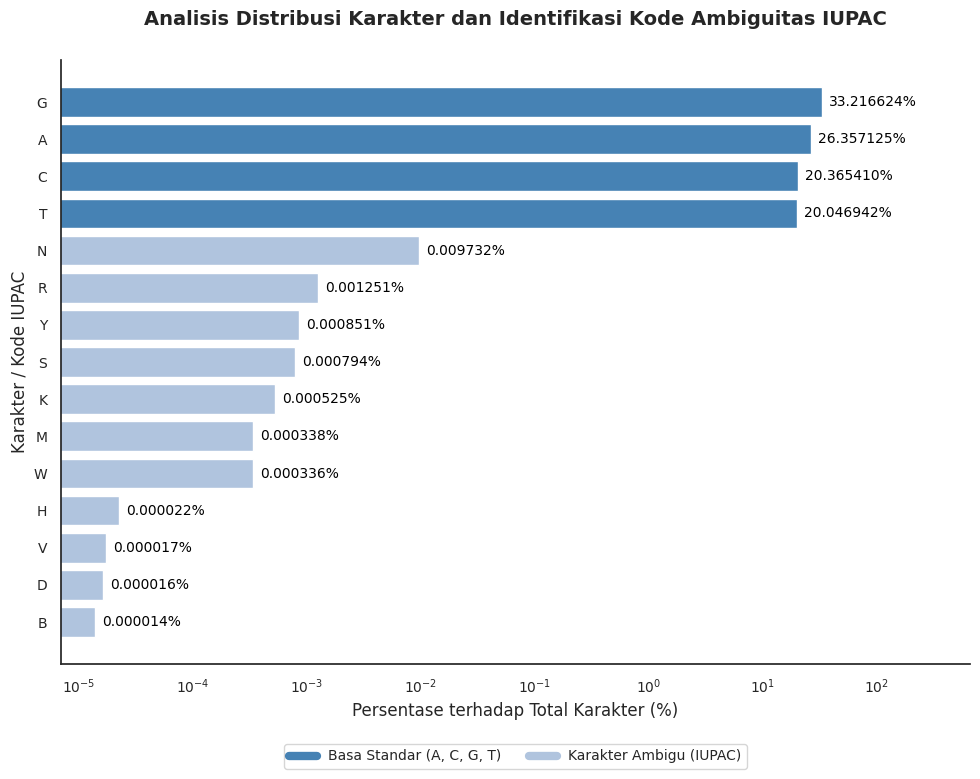

Waktu eksekusi: 9.24 detik
Visualisasi distribusi.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.lines import Line2D
# 1. Mulai Timer
start_time = time.time()
# =============================================================================
# VISUALISASI DISTRIBUSI KARAKTER SEKUENS (SOFT BLUE & TIMES NEW ROMAN)
# =============================================================================

# 1. PENGATURAN GLOBAL FONT (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']

sns.set_style("white")

# 2. HITUNG DISTRIBUSI KARAKTER
all_text = "".join(df_final['Sekuens'].astype(str))
total_chars = len(all_text)
char_counts = Counter(all_text)

char_data = [(char, (count / total_chars) * 100) for char, count in char_counts.items()]
char_data.sort(key=lambda x: x[1], reverse=True)
chars, percentages = zip(*char_data)

# 3. VISUALISASI
plt.figure(figsize=(10, 8))
plt.xscale('log')

standard_bases = ['A', 'C', 'G', 'T']
colors = ['steelblue' if c in standard_bases else 'lightsteelblue' for c in chars]

bars = plt.barh(
    chars[::-1],
    percentages[::-1],
    color=colors[::-1]
)

# 4. LABEL PERSENTASE (FORMAT SERAGAM)
for bar in bars:
    width = bar.get_width()
    label = f'{width:.6f}%'

    plt.text(
        width * 1.15,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        fontsize=10,
        color='black'
    )
# 5. JUDUL & LABEL
plt.title(
    'Analisis Distribusi Karakter dan Identifikasi Kode Ambiguitas IUPAC',
    fontsize=14,
    fontweight='bold',
    pad=25
)
plt.xlabel('Persentase terhadap Total Karakter (%)', fontsize=12)
plt.ylabel('Karakter / Kode IUPAC', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 6. LEGENDA
legend_elements = [
    Line2D([0], [0], color='steelblue', lw=6, label='Basa Standar (A, C, G, T)'),
    Line2D([0], [0], color='lightsteelblue', lw=6, label='Karakter Ambigu (IUPAC)')
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True,
    fontsize=10
)

# 7. FINALISASI
plt.xlim(min(percentages) * 0.5, max(percentages) * 20)
sns.despine()
plt.tight_layout()

plt.savefig(
    'distribusi_karakter_soft_blue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

print("Visualisasi distribusi.")

Waktu eksekusi: 9.11 detik


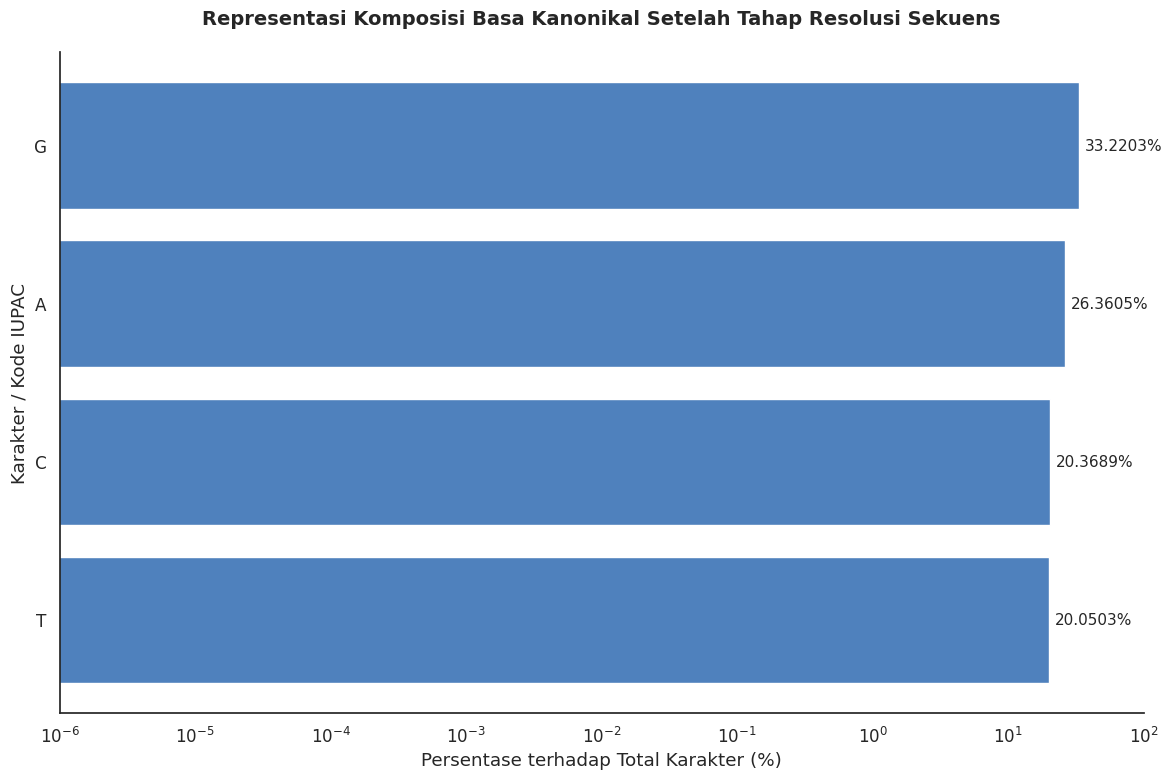

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
# 1. Mulai Timer
start_time = time.time()

# Style default putih
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
sns.set_style("white")

# Hitung distribusi
all_text_clean = "".join(df_final['Sekuens_cleaned'].astype(str))
total_chars_clean = len(all_text_clean)
char_counts = Counter(all_text_clean)

bases_order = ['G', 'A', 'C', 'T']

percentages = [
    (char_counts.get(base, 0) / total_chars_clean) * 100
    for base in bases_order
]

# Buat figure
plt.figure(figsize=(12, 8))

bars = plt.barh(
    bases_order[::-1],
    percentages[::-1],
    color='#4f81bd'
)

# LOG SCALE + BATAS MANUAL
plt.xscale('log')
plt.xlim(10**-6, 10**2)

# Atur tick supaya tampil dari 10^-6 sampai 10^2
ticks = [10**i for i in range(-6, 3)]
plt.xticks(ticks)

# Tambahkan label persentase
for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}%",
        va='center',
        fontsize=11
    )

# Judul & label
plt.title(
    "Representasi Komposisi Basa Kanonikal Setelah Tahap Resolusi Sekuens",
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.xlabel("Persentase terhadap Total Karakter (%)")
plt.ylabel("Karakter / Kode IUPAC")

sns.despine()
plt.tight_layout()
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)
plt.savefig("Gambar_4_4_Distribusi_Karakter_IUPAC.png", dpi=300)
plt.show()

# 9. K-mer

In [15]:
import time
import pandas as pd

K_VALUE = 6

start_time = time.time()

def get_kmers(sekuens, k):
    """Memecah sekuens DNA menjadi kata-kata k-mer dengan sliding window."""
    if not isinstance(sekuens, str) or len(sekuens) < k:
        return ""
    # Menghasilkan list k-mer dan menggabungkannya dengan spasi (format NLP)
    return " ".join([sekuens[i:i+k] for i in range(len(sekuens) - k + 1)])

# 3. EKSEKUSI PADA DATASET
print(f"-> Mengonversi sekuens bersih menjadi K-mer (k={K_VALUE})...")
df_final['kmers'] = df_final['Sekuens_cleaned'].apply(lambda x: get_kmers(x, K_VALUE))

print(f"Total Sampel : {len(df_final):,} baris")

# Validasi visual: Melihat k-mer pertama dari sampel pertama
if not df_final.empty:
    sample_kmers = df_final['kmers'].iloc[0].split()
    print(f"Contoh 5 K-mer pertama pada baris pertama:")
    print(f"   {sample_kmers[:5]}")

# 6. EKSPOR CHECKPOINT (K-MER + CLASS)
print("-" * 60)
file_name = f'dataset_kmers_k{K_VALUE}.csv'
print(f"-> Menyimpan checkpoint ke file: {file_name}")
df_final[['kmers', 'Class']].to_csv(file_name, index=False)

# 7. SELESAI
elapsed_time = time.time() - start_time
print(f"Selesai dalam {elapsed_time:.2f} detik")
print(f"STATUS: Kolom 'kmers' siap untuk tahap Vektorisasi.")
print("="*60)

-> Mengonversi sekuens bersih menjadi K-mer (k=6)...
Total Sampel : 277,586 baris
Contoh 5 K-mer pertama pada baris pertama:
   ['TGGGGA', 'GGGGAA', 'GGGAAT', 'GGAATT', 'GAATTT']
------------------------------------------------------------
-> Menyimpan checkpoint ke file: dataset_kmers_k6.csv
Selesai dalam 37.29 detik
STATUS: Kolom 'kmers' siap untuk tahap Vektorisasi.


In [16]:
start_time = time.time()
print(df_final['kmers'].head().to_string(index=False))
print(df_final['kmers'].tail().to_string(index=False))
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

       TGGGGA GGGGAA GGGAAT GGAATT GAATTT AATTTT ATTTTG TTTTGG TTTGGA TTGGAC TGGACA GGACAA GACAAT ACAATG CAATGG AATGGG ATGGGG TGGGGG GGGGGC GGGGCA GGGCAA GGCAAC GCAACC CAACCC AACCCT ACCCTG CCCTGA CCTGAT CTGATC TGATCC GATCCA ATCCAG TCCAGC CCAGCC CAGCCA AGCCAT GCCATC CCATCC CATCCC ATCCCG TCCCGC CCCGCG CCGCGT CGCGTG GCGTGT CGTGTG GTGTGC TGTGCG GTGCGA TGCGAT GCGATG CGATGA GATGAA ATGAAG TGAAGG GAAGGC AAGGCC AGGCCT GGCCTT GCCTTC CCTTCG CTTCGG TTCGGG TCGGGT CGGGTT GGGTTG GGTTGT GTTGTA TTGTAA TGTAAA GTAAAG TAAAGC AAAGCA AAGCAC AGCACT GCACTT CACTTT ACTTTT CTTTTG TTTTGG TTTGGC TTGGCA TGGCAG GGCAGG GCAGGA CAGGAA AGGAAA GGAAAG GAAAGA AAAGAA AAGAAA AGAAAC GAAACG AAACGG AACGGC ACGGCA CGGCAC GGCACG GCACGG CACGGG ACGGGC CGGGCT GGGCTA GGCTAA GCTAAT CTAATA TAATAT AATATC ATATCC TATCCT ATCCTG TCCTGT CCTGTG CTGTGC TGTGCA GTGCAA TGCAAC GCAACT CAACTG AACTGA ACTGAC CTGACG TGACGG GACGGT ACGGTA CGGTAC GGTACC GTACCT TACCTG ACCTGC CCTGCA CTGCAG TGCAGA GCAGAA CAGAAT AGAATA GAATAA AATAAG ATAAGC TAAGCA AAGCAC AGCACC

Sedang menghitung frekuensi K-mer pada dataset...


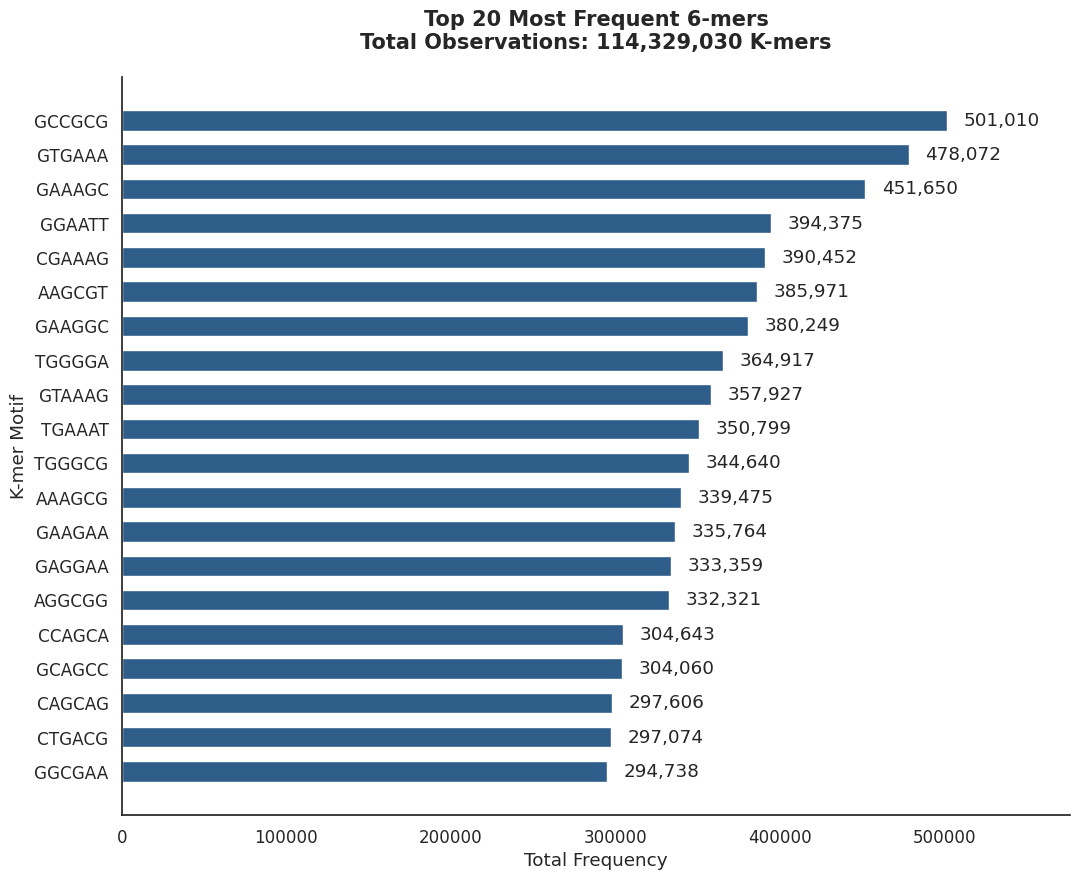

Waktu eksekusi: 26.42 detik


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
start_time = time.time()
sns.set_style("white")

print("Sedang menghitung frekuensi K-mer pada dataset...")

# Hitung frekuensi
all_kmers = " ".join(df_final['kmers']).split()
total_kmers_len = len(all_kmers)
kmer_counts = Counter(all_kmers)

top_20 = pd.DataFrame(
    kmer_counts.most_common(20),
    columns=['Kmer', 'Freq']
)

# Urut supaya terbesar di atas
top_20 = top_20.sort_values('Freq', ascending=True)

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(11, 9))

bars = plt.barh(
    top_20['Kmer'],
    top_20['Freq'],
    color='#2f5d8a',   # warna lebih gelap
    height=0.6        # lebih kecil = jarak lebih renggang
)

# Label angka
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (top_20['Freq'].max() * 0.02),
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center'
    )

plt.title(
    f"Top 20 Most Frequent {K_VALUE}-mers\n"
    f"Total Observations: {total_kmers_len:,} K-mers",
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel("Total Frequency")
plt.ylabel("K-mer Motif")

plt.xlim(0, top_20['Freq'].max() * 1.15)

sns.despine()
plt.tight_layout()

plt.savefig(f"top_20_kmers_k{K_VALUE}.png", dpi=300, bbox_inches='tight')
plt.show()
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

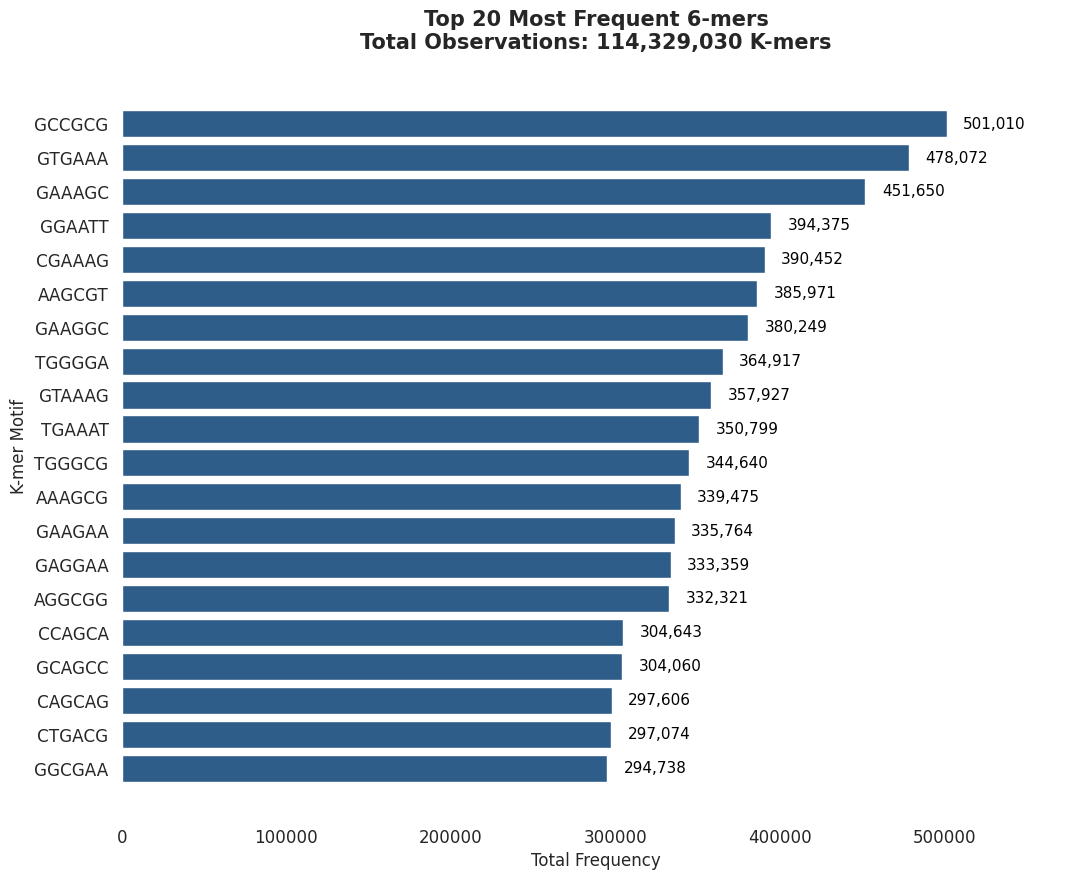

In [18]:
# =========================
# VISUALISASI TOP 20 K-MERS (BATANG LEBIH TEBAL)
# =========================
plt.figure(figsize=(11, 9))

bars = plt.barh(
    top_20['Kmer'],
    top_20['Freq'],
    color='#2f5d8a',  # warna biru estetik
    height=0.8         # lebih tebal, jarak antar bar lebih nyaman
)

# Label angka di ujung batang
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (top_20['Freq'].max() * 0.02),
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center',
        fontsize=11,
        color='black'
    )

plt.title(
    f"Top 20 Most Frequent {K_VALUE}-mers\n"
    f"Total Observations: {total_kmers_len:,} K-mers",
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel("Total Frequency", fontsize=12)
plt.ylabel("K-mer Motif", fontsize=12)

plt.xlim(0, top_20['Freq'].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(f"top_20_kmers_k{K_VALUE}_thick.png", dpi=300, bbox_inches='tight')
plt.show()

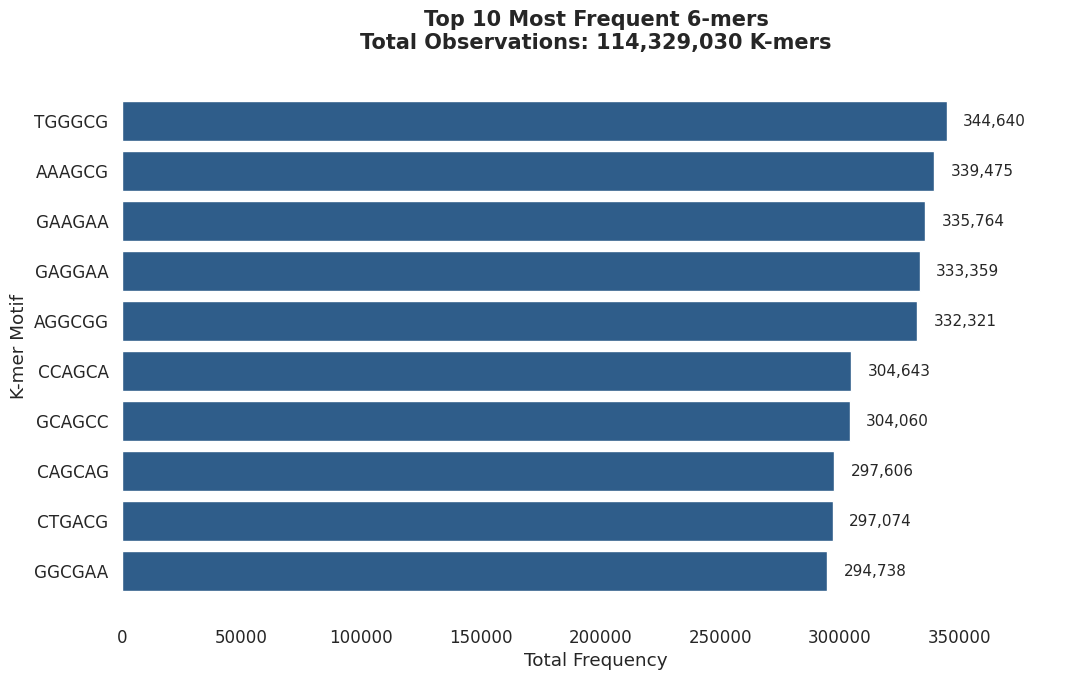

In [19]:
# =========================
# VISUALISASI TOP 10 K-MERS
# =========================
top_10 = top_20.head(10)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_10['Kmer'],
    top_10['Freq'],
    color='#2f5d8a',
    height=0.8
)

# Label angka
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (top_10['Freq'].max() * 0.02),
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center',
        fontsize=11
    )

plt.title(
    f"Top 10 Most Frequent {K_VALUE}-mers\n"
    f"Total Observations: {total_kmers_len:,} K-mers",
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.xlabel("Total Frequency")
plt.ylabel("K-mer Motif")

plt.xlim(0, top_10['Freq'].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig(f"top_10_kmers_k{K_VALUE}.png", dpi=300, bbox_inches='tight')
plt.show()

# 10. Pembagian Data (Stratified Hold-Out Split)

In [20]:
start_time = time.time()
X = df_final['kmers']
y = df_final['Class']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.125, # 0.125 * 0.8 = 0.1 (10% dari total)
    random_state=42, 
    stratify=y_temp
)

# 4. STATISTIK & VERIFIKASI
total = len(df_final)
print(f"Pembagian Selesai!")
print("-" * 60)
print(f"{'Set Data':<15} | {'Jumlah Sampel':<15} | {'Persentase':<10}")
print("-" * 60)
print(f"{'Training':<15} | {len(X_train):<15,} | {(len(X_train)/total)*100:>8.1f}%")
print(f"{'Validation':<15} | {len(X_val):<15,} | {(len(X_val)/total)*100:>8.1f}%")
print(f"{'Testing':<15} | {len(X_test):<15,} | {(len(X_test)/total)*100:>8.1f}%")
print("-" * 60)
print("Proporsi Kelas di Tiap Set (Harus Identik):")
dist_df = pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True) * 100,
    'Val (%)': y_val.value_counts(normalize=True) * 100,
    'Test (%)': y_test.value_counts(normalize=True) * 100
})
print(dist_df.round(2))
print("="*60)
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

Pembagian Selesai!
------------------------------------------------------------
Set Data        | Jumlah Sampel   | Persentase
------------------------------------------------------------
Training        | 194,309         |     70.0%
Validation      | 27,759          |     10.0%
Testing         | 55,518          |     20.0%
------------------------------------------------------------
Proporsi Kelas di Tiap Set (Harus Identik):
                    Train (%)  Val (%)  Test (%)
Class                                           
4-29-1                   0.02     0.02      0.02
ABY1                     0.14     0.14      0.14
AD3                      0.03     0.03      0.03
Abditibacteria           0.06     0.06      0.06
Acetothermiia            0.06     0.06      0.06
...                       ...      ...       ...
WS2                      0.02     0.02      0.02
Zetaproteobacteria       0.04     0.04      0.04
Zixibacteria             0.07     0.07      0.07
bacteriap25              0.13 

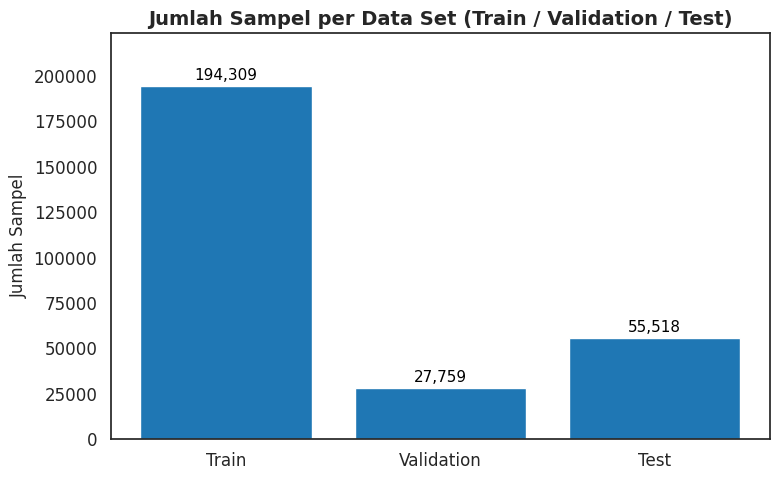

In [21]:
import matplotlib.pyplot as plt

# =========================
# HISTOGRAM TOTAL SAMPEL PER SET ESTETIK (CLEAN)
# =========================
sets = ['Train', 'Validation', 'Test']
counts = [len(X_train), len(X_val), len(X_test)]

plt.figure(figsize=(8,5))

# Warna biru estetik
colors = ['#1f77b4', '#1f77b4', '#1f77b4']

bars = plt.bar(sets, counts, color=colors)

# Label batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(counts)*0.01,
        f'{height:,}',
        ha='center',
        va='bottom',
        fontsize=11,
        color='black'
    )

plt.ylabel('Jumlah Sampel', fontsize=12)
plt.title('Jumlah Sampel per Data Set (Train / Validation / Test)', fontsize=14, fontweight='bold')
plt.ylim(0, max(counts)*1.15)  # kasih space untuk angka di atas batang

plt.tight_layout()

# Simpan grafik
plt.savefig('histogram_total_sampel_clean.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. K-mer menjadi Numerik (CountVectorizer)

In [22]:
start_time = time.time()
print("Mengonversi K-mer menjadi matriks frekuensi...")

vectorizer = CountVectorizer(lowercase=False)

# 1. FIT & TRANSFORM DATA TRAIN
X_train_vec = vectorizer.fit_transform(X_train)  

# 2. TRANSFORM DATA VAL & TEST
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

# 3. LAPORAN HASIL DIMENSI
print("-" * 60)
print("HASIL EKSTRAKSI FITUR K-MER:")
feature_names = vectorizer.get_feature_names_out()

print(f"-> Jumlah Fitur K-mer Unik : {len(feature_names):,}")
print(f"-> Dimensi X_train_vec      : {X_train_vec.shape}")
print(f"-> Dimensi X_val_vec        : {X_val_vec.shape}")
print(f"-> Dimensi X_test_vec       : {X_test_vec.shape}")

# 4. PREVIEW (SINKRONISASI X DAN Y)
print("\n[PREVIEW 10 SAMPEL PERTAMA – 10 FITUR K-MER PERTAMA]")
preview_cols = feature_names[:10]

# Membuat DataFrame dari potongan matriks sparse (10 baris x 10 kolom pertama)
full_preview = pd.DataFrame(
    X_train_vec[:10, :10].toarray(), 
    columns=preview_cols
)

y_preview = y_train.iloc[:10].reset_index(drop=True)
full_preview.insert(0, 'TARGET_CLASS', y_preview)

display(full_preview)

# 5. FINALISASI VARIABEL UNTUK IPCA
X_train_final = X_train_vec
X_val_final = X_val_vec
X_test_final = X_test_vec

# Target y tetap menggunakan hasil split (y_train, y_val, y_test)
y_train_final = y_train
y_val_final = y_val
y_test_final = y_test

print("-" * 60)
print(f"Waktu proses: {time.time() - start_time:.2f} detik")
print("STATUS: Matriks Sparse Berhasil Dibuat.")
print("INFO: X_train_final siap di-input ke IncrementalPCA (IPCA).")
print("="*60)

Mengonversi K-mer menjadi matriks frekuensi...
------------------------------------------------------------
HASIL EKSTRAKSI FITUR K-MER:
-> Jumlah Fitur K-mer Unik : 4,096
-> Dimensi X_train_vec      : (194309, 4096)
-> Dimensi X_val_vec        : (27759, 4096)
-> Dimensi X_test_vec       : (55518, 4096)

[PREVIEW 10 SAMPEL PERTAMA – 10 FITUR K-MER PERTAMA]


,TARGET_CLASS,AAAAAA,AAAAAC,AAAAAG,AAAAAT,AAAACA,AAAACC,AAAACG,AAAACT,AAAAGA,AAAAGC
0,Symbiobacteriia,0,0,0,0,0,0,0,0,0,0
1,JS1,0,0,0,0,0,0,0,0,0,0
2,Clostridia,0,0,0,0,0,0,0,0,0,0
3,Clostridia,0,0,0,0,0,0,0,0,0,0
4,Gammaproteobacteria,0,0,0,0,0,0,0,0,0,0
5,Bacteroidia,0,0,0,0,0,0,0,0,0,0
6,Campylobacteria,0,0,0,0,0,0,0,0,0,0
7,Clostridia,0,0,0,0,0,0,0,0,0,0
8,Clostridia,0,0,0,0,1,0,0,1,0,0
9,Clostridia,2,0,0,1,0,0,0,0,0,0


------------------------------------------------------------
Waktu proses: 78.01 detik
STATUS: Matriks Sparse Berhasil Dibuat.
INFO: X_train_final siap di-input ke IncrementalPCA (IPCA).


In [23]:
start_time = time.time()
# 1. Pilih kolom fitur yang ingin ditampilkan (misal 10 fitur pertama)
preview_features = feature_names[:10]

# 2. Ambil data Train (Head 10 & Tail 10)
X_head = X_train_final[:10, :10].toarray()
X_tail = X_train_final[-10:, :10].toarray()

# 3. Ambil target y yang sesuai
y_head = y_train_final.iloc[:10].values
y_tail = y_train_final.iloc[-10:].values

df_head = pd.DataFrame(X_head, columns=preview_features)
df_head.insert(0, 'TARGET_CLASS', y_head)
df_head.index = [f"Head_{i}" for i in range(1, 11)]

df_tail = pd.DataFrame(X_tail, columns=preview_features)
df_tail.insert(0, 'TARGET_CLASS', y_tail)
df_tail.index = [f"Tail_{i}" for i in range(1, 11)]
print("\n[10 DATA TERATAS (HEAD)]")
display(df_head)

print("\n" + "-"*30)
print("[10 DATA TERBAWAH (TAIL)]")
display(df_tail)

print("\n" + "="*70)
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)


[10 DATA TERATAS (HEAD)]


,TARGET_CLASS,AAAAAA,AAAAAC,AAAAAG,AAAAAT,AAAACA,AAAACC,AAAACG,AAAACT,AAAAGA,AAAAGC
Head_1,Symbiobacteriia,0,0,0,0,0,0,0,0,0,0
Head_2,JS1,0,0,0,0,0,0,0,0,0,0
Head_3,Clostridia,0,0,0,0,0,0,0,0,0,0
Head_4,Clostridia,0,0,0,0,0,0,0,0,0,0
Head_5,Gammaproteobacteria,0,0,0,0,0,0,0,0,0,0
Head_6,Bacteroidia,0,0,0,0,0,0,0,0,0,0
Head_7,Campylobacteria,0,0,0,0,0,0,0,0,0,0
Head_8,Clostridia,0,0,0,0,0,0,0,0,0,0
Head_9,Clostridia,0,0,0,0,1,0,0,1,0,0
Head_10,Clostridia,2,0,0,1,0,0,0,0,0,0



------------------------------
[10 DATA TERBAWAH (TAIL)]


,TARGET_CLASS,AAAAAA,AAAAAC,AAAAAG,AAAAAT,AAAACA,AAAACC,AAAACG,AAAACT,AAAAGA,AAAAGC
Tail_1,Bacteroidia,1,0,1,0,0,0,0,0,0,0
Tail_2,Verrucomicrobiae,0,0,0,0,0,0,0,0,0,0
Tail_3,Gammaproteobacteria,0,0,0,0,0,0,0,0,0,0
Tail_4,Alphaproteobacteria,0,0,0,0,0,0,0,0,0,0
Tail_5,Gammaproteobacteria,0,0,1,0,0,0,0,0,0,0
Tail_6,Bacteroidia,0,0,0,0,0,0,0,0,0,0
Tail_7,Desulfitobacteriia,0,0,0,0,0,0,0,0,0,0
Tail_8,Bacteroidia,0,0,0,0,0,0,0,0,0,0
Tail_9,Clostridia,0,0,0,0,0,0,1,1,0,0
Tail_10,Alphaproteobacteria,0,0,0,0,0,0,0,1,0,0



Waktu eksekusi: 0.02 detik


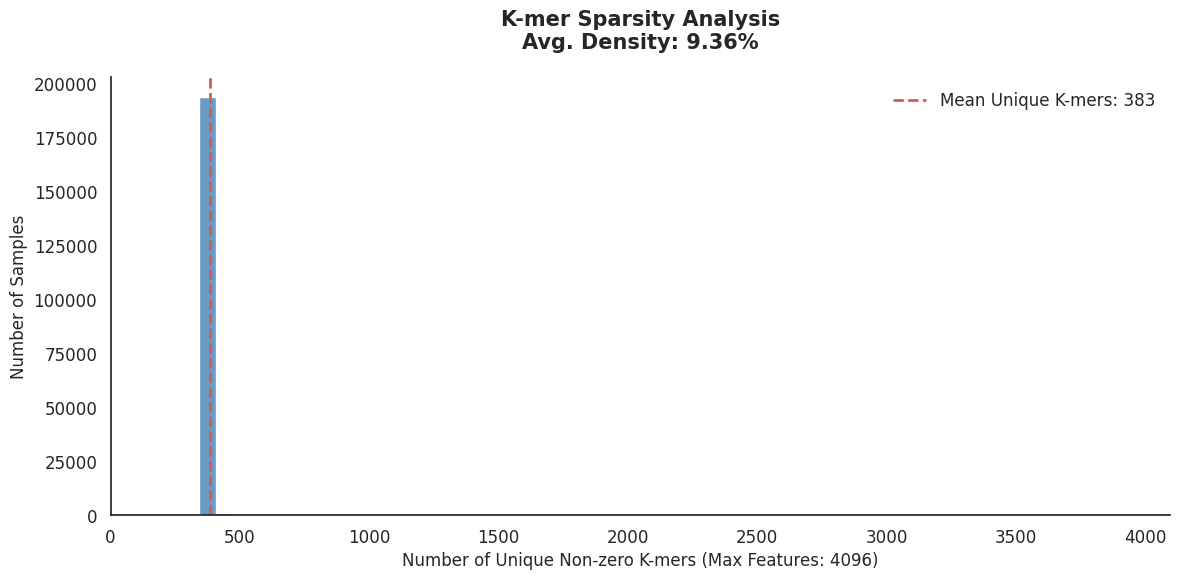

Analisis Sparsity selesai.
-> Total fitur: 4096
-> Rata-rata K-mer unik per sampel: 383.48
-> Density: 9.36%
Waktu eksekusi: 4.80 detik


In [24]:
start_time = time.time()
non_zero_counts = np.array((X_train_final > 0).sum(axis=1)).flatten()

total_features = X_train_final.shape[1] 
avg_non_zero = non_zero_counts.mean()
sparsity_pct = (avg_non_zero / total_features) * 100

# 3. Plotting
plt.figure(figsize=(12, 6), dpi=100)
sns.set_style("white")

sns.histplot(
    non_zero_counts, 
    bins=60, 
    color='steelblue', 
    alpha=0.8, 
    binrange=(0, total_features), 
    edgecolor=None
)

plt.axvline(
    avg_non_zero, 
    color='indianred', 
    linestyle='--', 
    linewidth=2, 
    label=f'Mean Unique K-mers: {avg_non_zero:.0f}'
)

plt.title(f'K-mer Sparsity Analysis\nAvg. Density: {sparsity_pct:.2f}%', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f'Number of Unique Non-zero K-mers (Max Features: {total_features})', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Batas sumbu X
plt.xlim(0, total_features) 

# Estetika akhir
plt.legend(frameon=False)
sns.despine()

plt.tight_layout()

# 6. Simpan
plt.savefig('kmer_sparsity_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Analisis Sparsity selesai.")
print(f"-> Total fitur: {total_features}")
print(f"-> Rata-rata K-mer unik per sampel: {avg_non_zero:.2f}")
print(f"-> Density: {sparsity_pct:.2f}%")
# 6. SELESAI
end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

# 12. Reduksi Dimensi (IPCA)

[PROSES 1] Normalisasi fitur menggunakan StandardScaler...

[PROSES 2] Fitting IPCA pada 194,309 sampel...
    -> Memproses batch 95/95...
    -> Fitting selesai.


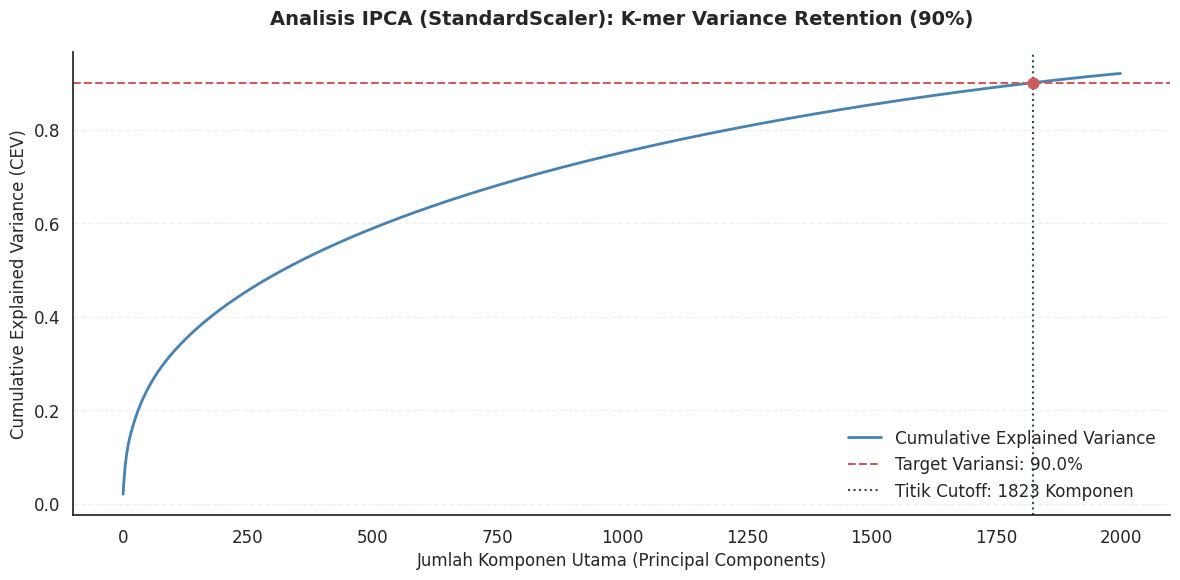


[PROSES 3] Transformasi Data ke 1823 Dimensi...
------------------------------------------------------------
Hasil Akhir Reduksi Dimensi:
Variance Retained : 90.0087%
Total Dimensi Baru: 1823
Total Waktu IPCA  : 2816.94 detik
STATUS: Reduksi Dimensi dengan StandardScaler Selesai.
INFO: X_train_pca, X_val_pca, X_test_pca siap digunakan untuk KNN/GNB.


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

start_time_ipca = time.time()

# ---------------------------------------------------------
# 1. NORMALISASI MENGGUNAKAN STANDARDSCALER
# ---------------------------------------------------------
print("[PROSES 1] Normalisasi fitur menggunakan StandardScaler...")
# CATATAN TEKNIS: with_mean=False digunakan karena data k-mer biasanya sparse.
# Centering (mean=True) akan merusak struktur sparse dan menghabiskan RAM.
# Scaling unit variance tetap dilakukan untuk memenuhi asumsi GNB & KNN.
scaler = StandardScaler(with_mean=False) 

# Menggunakan X_train_final, X_val_final, dan X_test_final dari tahap sebelumnya
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

# ---------------------------------------------------------
# 2. KONFIGURASI IPCA
# ---------------------------------------------------------
N_COMPONENTS_MAX = 2000 
BATCH_SIZE = 2048 
TARGET_VARIANCE = 0.90 

ipca = IncrementalPCA(n_components=N_COMPONENTS_MAX, batch_size=BATCH_SIZE)

# ---------------------------------------------------------
# 3. FITTING PROCESS (BATCH BY BATCH)
# ---------------------------------------------------------
print(f"\n[PROSES 2] Fitting IPCA pada {X_train_scaled.shape[0]:,} sampel...")
total_chunks = int(np.ceil(X_train_scaled.shape[0] / BATCH_SIZE))

for i in range(0, X_train_scaled.shape[0], BATCH_SIZE):
    # Konversi ke dense (.toarray()) hanya dilakukan per batch untuk efisiensi RAM
    batch = X_train_scaled[i:i+BATCH_SIZE].toarray()
    ipca.partial_fit(batch)
    if (i // BATCH_SIZE) % 5 == 0 or i + BATCH_SIZE >= X_train_scaled.shape[0]:
        print(f"\r    -> Memproses batch {int(i/BATCH_SIZE)+1}/{total_chunks}...", end="")

print("\n    -> Fitting selesai.")

# ---------------------------------------------------------
# 4. ANALISIS VARIANCE & VISUALISASI
# ---------------------------------------------------------
cumulative_variance = np.cumsum(ipca.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= TARGET_VARIANCE) + 1

plt.figure(figsize=(12, 6), dpi=100)
sns.set_style("white") 

# Plot garis Cumulative Explained Variance (CEV)
plt.plot(cumulative_variance, label='Cumulative Explained Variance', color='steelblue', linewidth=2)

# Garis ambang batas target 90%
plt.axhline(y=TARGET_VARIANCE, color='indianred', linestyle='--', 
            label=f'Target Variansi: {TARGET_VARIANCE*100}%')

# Garis potong komponen optimal
plt.axvline(x=n_components_90, color='darkslategray', linestyle=':', 
            label=f'Titik Cutoff: {n_components_90} Komponen')

plt.scatter(
    n_components_90,
    cumulative_variance[n_components_90 - 1],
    color='indianred', s=60, zorder=5
)

plt.xlabel('Jumlah Komponen Utama (Principal Components)', fontsize=12)
plt.ylabel('Cumulative Explained Variance (CEV)', fontsize=12)
plt.title('Analisis IPCA (StandardScaler): K-mer Variance Retention (90%)', fontsize=14, fontweight='bold', pad=20)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()

plt.savefig('ipca_variance_90_standardscaler.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 5. TRANSFORMASI FINAL (PROSES PER BATCH)
# ---------------------------------------------------------
print(f"\n[PROSES 3] Transformasi Data ke {n_components_90} Dimensi...")

def transform_data_in_batches(model, X_data, b_size, n_keep):
    transformed = []
    for i in range(0, X_data.shape[0], b_size):
        batch = X_data[i:i+b_size].toarray()
        # Melakukan transformasi dan memotong komponen sesuai cutoff target variance
        transformed.append(model.transform(batch)[:, :n_keep])
    return np.vstack(transformed)

X_train_pca = transform_data_in_batches(ipca, X_train_scaled, BATCH_SIZE, n_components_90)
X_val_pca = transform_data_in_batches(ipca, X_val_scaled, BATCH_SIZE, n_components_90)
X_test_pca = transform_data_in_batches(ipca, X_test_scaled, BATCH_SIZE, n_components_90)

print("-" * 60)
print(f"Hasil Akhir Reduksi Dimensi:")
print(f"Variance Retained : {cumulative_variance[n_components_90-1]:.4%}")
print(f"Total Dimensi Baru: {n_components_90}")
print(f"Total Waktu IPCA  : {time.time() - start_time_ipca:.2f} detik")
print("STATUS: Reduksi Dimensi dengan StandardScaler Selesai.")
print("INFO: X_train_pca, X_val_pca, X_test_pca siap digunakan untuk KNN/GNB.")
print("="*60)

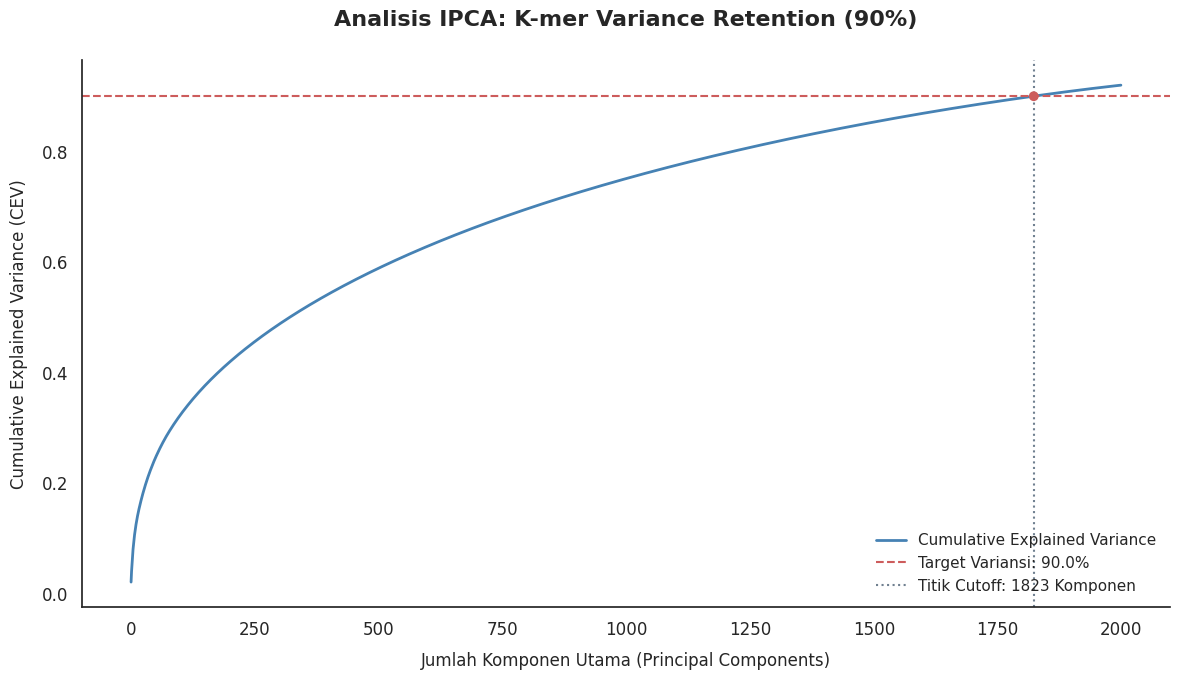

Visualisasi selesai. Disimpan sebagai: ipca_variance_analysis_final.png


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# VISUALISASI VARIANSI KUMULATIF (STYLE MATCHED)
# ---------------------------------------------------------
# Menggunakan style white agar bersih seperti di gambar
sns.set_style("white") 

plt.figure(figsize=(12, 7), dpi=100)

# 1. Plot Utama: Cumulative Explained Variance
plt.plot(cumulative_variance, 
         label='Cumulative Explained Variance', 
         color='#4682B4', # Warna biru baja yang mirip di gambar
         linewidth=2, 
         zorder=2)

# 2. Garis Ambang Batas Target (Merah Putus-putus)
plt.axhline(y=TARGET_VARIANCE, 
            color='#CD5C5C', # Indian Red
            linestyle='--', 
            linewidth=1.5,
            label=f'Target Variansi: {TARGET_VARIANCE*100}%')

# 3. Garis Vertikal Titik Potong (Abu-abu Titik-titik)
plt.axvline(x=n_components_90, 
            color='#708090', # Slate Gray
            linestyle=':', 
            linewidth=1.5,
            label=f'Titik Cutoff: {n_components_90} Komponen')

# 4. Titik Merah pada Titik Cutoff
plt.scatter(n_components_90, 
            cumulative_variance[n_components_90 - 1], 
            color='#CD5C5C', 
            s=50, 
            edgecolor='none',
            zorder=5)

# 5. Konfigurasi Judul & Axis (Sesuai Permintaan)
plt.title('Analisis IPCA: K-mer Variance Retention (90%)', 
          fontsize=16, fontweight='bold', pad=25)

plt.xlabel('Jumlah Komponen Utama (Principal Components)', fontsize=12, labelpad=10)
plt.ylabel('Cumulative Explained Variance (CEV)', fontsize=12, labelpad=10)

# Menghilangkan garis tepi atas dan kanan agar minimalis
sns.despine()

# 7. Legenda di Kanan Bawah
plt.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()

# 8. SIMPAN HASIL KE KAGGLE
output_name = 'ipca_variance_analysis_final.png'
plt.savefig(output_name, dpi=300, bbox_inches='tight')

plt.show()

print(f"Visualisasi selesai. Disimpan sebagai: {output_name}")

In [27]:
# Misal n_components_90 sudah didefinisikan sebelumnya
start_time = time.time()

# Membuat nama kolom PC
pc_columns = [f'PC{i+1}' for i in range(n_components_90)]

# Konversi ke DataFrame
df_train_ipca = pd.DataFrame(X_train_pca, columns=pc_columns)
df_val_ipca   = pd.DataFrame(X_val_pca, columns=pc_columns)
df_test_ipca  = pd.DataFrame(X_test_pca, columns=pc_columns)

# Menambahkan label
df_train_ipca['Class'] = y_train.reset_index(drop=True)
df_val_ipca['Class']   = y_val.reset_index(drop=True)
df_test_ipca['Class']  = y_test.reset_index(drop=True)

# Tampilkan 5 baris pertama
print("DataFrame Train (5 baris terakhir):")
print(df_train_ipca.tail())

end_time = time.time()
print(f"Waktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

DataFrame Train (5 baris terakhir):
              PC1       PC2       PC3       PC4        PC5       PC6  \
194304  25.656942 -4.599977  0.031800  0.065622  -0.465825 -0.135974   
194305  -6.949426 -7.307193 -2.894117  4.021582   1.047587 -0.594862   
194306  21.030465 -3.341104  0.134294 -2.536006  -0.309184  0.978852   
194307  -5.101624 -6.701122  3.892599  5.516173   1.162578 -1.206012   
194308  -2.811250  5.860282 -3.710480  4.091265  18.844439 -0.365870   

             PC7       PC8       PC9      PC10      PC11      PC12       PC13  \
194304  3.927445 -4.481068 -2.957575 -1.121431 -1.936494  0.531761   6.401405   
194305 -1.619099 -3.110970 -1.474992 -4.354319 -3.147852 -3.818394  -1.719952   
194306  0.629802  3.825288 -0.328333 -2.074224  0.764568 -2.261742  10.752939   
194307 -6.327604 -1.691966  3.657281 -0.980018 -6.996671 -1.232809  -9.163739   
194308  9.508273 -2.323792  2.986458 -0.488506  4.339519  2.019361  -0.853530   

             PC14      PC15       PC16      

In [28]:
# Misal n_components_90 sudah didefinisikan sebelumnya
start_time = time.time()

# Membuat nama kolom PC
pc_columns = [f'PC{i+1}' for i in range(n_components_90)]

# Konversi ke DataFrame
df_train_ipca = pd.DataFrame(X_train_pca, columns=pc_columns)
df_val_ipca   = pd.DataFrame(X_val_pca, columns=pc_columns)
df_test_ipca  = pd.DataFrame(X_test_pca, columns=pc_columns)

# Menambahkan label
df_train_ipca['Class'] = y_train.reset_index(drop=True)
df_val_ipca['Class']   = y_val.reset_index(drop=True)
df_test_ipca['Class']  = y_test.reset_index(drop=True)

# =========================
# TAMPILKAN DATA
# =========================
print("DataFrame Train (5 baris pertama):")
print(df_train_ipca.head())

print("\nDataFrame Train (5 baris terakhir):")
print(df_train_ipca.tail())

end_time = time.time()
print(f"\nWaktu eksekusi: {end_time - start_time:.2f} detik")
print("="*60)

DataFrame Train (5 baris pertama):
        PC1       PC2       PC3        PC4        PC5       PC6       PC7  \
0 -6.923188 -3.057075  2.302811   0.350649   1.129448  2.956892 -1.217059   
1 -2.259415 -5.444427  1.548582  -4.380987   2.177188 -1.482424 -5.248405   
2 -8.270559 -9.183219  6.027219  27.430165 -10.401908 -0.043881  1.182228   
3 -8.217937 -9.136481  5.567252  28.387911 -10.687765  1.317543  2.777620   
4  0.027436  9.121512  0.622368  -2.195903  -0.364035 -0.308743 -0.321061   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  4.546788 -0.703754 -3.417988 -2.801734 -7.217259  1.241397 -1.459550   
1 -0.195862 -3.961524  0.058551 -1.605980  0.048031 -5.686400  1.102937   
2  0.403495  0.182646  0.269625  2.380821  4.329822  5.107376  4.963740   
3 -0.112184  0.216773  0.270551  2.451179  2.282140  3.790920  4.466278   
4  3.487489  0.639705 -4.045421 -2.532890 -2.939307  7.878543  2.748955   

       PC15      PC16      PC17      PC18      PC19

# 13. Visualisasi 3D IPCA

In [29]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import numpy as np
import pandas as pd

# Renderer khusus Kaggle
pio.renderers.default = "iframe"

# =========================
# SAMPLING
# =========================
N_SAMPLE = 5000
np.random.seed(42)
idx = np.random.choice(len(X_train_pca), size=min(N_SAMPLE, len(X_train_pca)), replace=False)

X_vis = X_train_pca[idx, :3]
y_vis = np.array(y_train_final)[idx]

df = pd.DataFrame({
    'PC1'  : X_vis[:, 0],
    'PC2'  : X_vis[:, 1],
    'PC3'  : X_vis[:, 2],
    'Kelas': y_vis.astype(str)
})

unique_labels = sorted(df['Kelas'].unique())
n_labels      = len(unique_labels)

colors_list = px.colors.sample_colorscale(
    "hsv", [i / n_labels for i in range(n_labels)]
)
color_map = {lbl: colors_list[i] for i, lbl in enumerate(unique_labels)}

# =========================
# TRACE PER KELAS
# =========================
traces = []
for lbl in unique_labels:
    sub = df[df['Kelas'] == lbl]
    traces.append(go.Scatter3d(
        x    = sub['PC1'],
        y    = sub['PC2'],
        z    = sub['PC3'],
        mode = 'markers',
        name = lbl,
        marker = dict(size=3, color=color_map[lbl], opacity=0.75),
        hovertemplate = (
            f"<b>Kelas: {lbl}</b><br>"
            "PC1: %{x:.4f}<br>"
            "PC2: %{y:.4f}<br>"
            "PC3: %{z:.4f}<extra></extra>"
        )
    ))

# =========================
# LAYOUT
# =========================
pc1_var = ipca.explained_variance_ratio_[0] * 100
pc2_var = ipca.explained_variance_ratio_[1] * 100
pc3_var = ipca.explained_variance_ratio_[2] * 100

fig = go.Figure(data=traces)
fig.update_layout(
    title = dict(
        text = (
            f'Visualisasi 3D IPCA Interaktif — {n_labels} Kelas (Train)<br>'
            f'<sup>Variance PC1+PC2+PC3: {pc1_var+pc2_var+pc3_var:.2f}%</sup>'
        ),
        x=0.5, font=dict(size=15, color='black')
    ),
    scene = dict(
        xaxis_title = f'PC1 ({pc1_var:.2f}%)',
        yaxis_title = f'PC2 ({pc2_var:.2f}%)',
        zaxis_title = f'PC3 ({pc3_var:.2f}%)',
        bgcolor     = 'white',
        xaxis = dict(backgroundcolor='rgb(235,240,255)', gridcolor='rgba(0,0,0,0.1)', color='black'),
        yaxis = dict(backgroundcolor='rgb(235,255,240)', gridcolor='rgba(0,0,0,0.1)', color='black'),
        zaxis = dict(backgroundcolor='rgb(255,235,235)', gridcolor='rgba(0,0,0,0.1)', color='black'),
    ),
    paper_bgcolor = 'white',
    plot_bgcolor  = 'white',
    font          = dict(color='black'),
    legend = dict(
        title      = dict(text='Kelas', font=dict(size=10, color='black')),
        itemsizing = 'constant',
        font       = dict(size=7, color='black'),
        yanchor    = 'top', y=1,
        xanchor    = 'left', x=1.01,
        bgcolor    = 'rgba(255,255,255,0.8)',
        bordercolor= 'rgba(0,0,0,0.1)',
        borderwidth= 1,
    ),
    margin = dict(l=0, r=220, b=0, t=80),
    width  = 1100,
    height = 750,
)
fig.write_html('/kaggle/working/ipca_3d_interactive.html')
fig.show()

print(f"Total kelas tampil : {n_labels}")
print("Buka juga di      : /kaggle/working/ipca_3d_interactive.html")

Total kelas tampil : 152
Buka juga di      : /kaggle/working/ipca_3d_interactive.html
